<a href="https://colab.research.google.com/github/peanuts05-6c6e797671xeh7iicsa/rsa-shor-article/blob/main/notebooks/rsa-shor-handson-en-latest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Factoring $n=15$ with Shor's Algorithm — A Hands-On Look at How RSA Gets Broken**

**Author**: Jorge Amari (甘利 丈慈)　**Version**: v1.1.0-en (2026-07)　**License**: CC-BY-NC-ND-4.0 (text and figures) / MIT (code)


![image.png](https://qiita-image-store.s3.ap-northeast-1.amazonaws.com/0/3974753/1e9f98ae-1431-43d4-802c-90531f6dbb02.png)


## **0. Introduction**

"Once quantum computers are fully realized, RSA encryption will be broken" — this phrase is widely known.

Much of today's intense public interest in quantum computing surely stems from the fact that we humans rely heavily on RSA encryption, and that its security would be undermined by a quantum computer.\
Against the backdrop of research progress, growing investment, and the ongoing discussion of migration to post-quantum cryptography (PQC), attention to this field is expected to keep growing.

Quantum topics, however, are sometimes wildly overhyped, and quantum computers are at times described as if they were magic. Rather than relying on sensational headlines, we want you to understand the substance correctly and to be able to verify with your own hands what is possible today and what is not.

This hands-on therefore focuses on the application of quantum computers with the greatest societal impact — breaking RSA encryption — and, taking "factoring n=15 with Shor's algorithm" as its subject, builds up the quantum circuit step by step starting from adders and runs it on a simulator. It is structured so that you can run the code yourself and see exactly how a quantum computer breaks RSA.

As the theory companion to this hands-on, we provide a separate PDF, *Why RSA Is Still Safe — and How a Quantum Computer Would Break It* (hereafter "the Book").  Whenever you find yourself wondering "why does this work?" or wanting more of the mathematical background as you work through the hands-on, see the relevant section of the Book (where helpful, individual cells include links of the form → Book, Section X.Y).


### **0.1 What You Will Do in This Hands-On**





We often hear that "a quantum computer can break RSA encryption" — but how, concretely, is it broken? This is what you will get a feel for here.

The security of RSA rests on the fact that factoring large numbers cannot be done in a realistic amount of time by classical computation (→ Book, Chapter 2). If there were an algorithm that factors efficiently, RSA would be broken. Shor's algorithm is exactly that method.

In this hands-on, taking the factorization of $n = 15$ as our subject, we first stay entirely classical (nothing quantum yet): we confirm the relationship between the order and the prime factors, and get a feel for the fact that a naive classical computation takes exponential time to find that order. (Even the best known classical method takes subexponential time.)

Next, we build up the quantum circuit for Shor's algorithm step by step, starting from constructing the adders, and run it on a simulator to complete the factorization. Finally, we simulate what happens when "NISQ devices" (noisy intermediate-scale quantum) — today's mainstream quantum computers, used for relatively shallow circuits and limited applications — are applied as-is to a large, deep circuit like Shor's, and come to understand why stable execution requires FTQC (fault-tolerant quantum computing).

| Part | Contents | Corresponding Sections of the Book |
|-------|------|----------|
| Chapter 1: The Order-Finding Problem | Definition of the order; from the order to the factors; the limits of classical computation | (→ Book, "The Order-Finding Problem") |
| Chapter 2: Running Shor's Algorithm | Build the circuit step by step from adders, run it on a simulator, and complete the factorization | (→ Book, "The Steps of Shor's Algorithm", "Implementation") |
| Chapter 3: The Gap Between Ideal and Real | The gap to today's devices in terms of circuit size; the impact of noise | (→ Book, "Practicality Analysis") |
| Closing Remarks | Summary of this hands-on | |

Concretely, we will do the following:

1. **Experience the relationship between the order and factorization** (classical computation) \
Confirm that once the $r$ (the order) satisfying $a^r \equiv 1 \pmod{n}$ is known, the prime factors can be found with nothing more than $\gcd$
2. **Get a feel for the limits of classical computation**\
See that with classical computation, the time needed to find the order explodes as $n$ grows, leaving RSA-2048 hopelessly out of reach
3. **Construct the quantum circuit one step at a time**\
Build up the quantum circuit for Shor's algorithm step by step, starting from constructing the adders, and run it on a simulator
4. **Complete the factorization from the measurement results**\
Recover the order from the circuit output via the continued-fraction expansion and derive $15 = 3 \times 5$
5. **Examine the gap between ideal and real**\
Grasp how far today's devices are from what the circuit size demands, and observe how the results degrade in a noisy simulation

Items 1–4 above are the body of Shor's algorithm itself; item 5 examines the gap to today's quantum computers.





### **0.2 Before You Run the Notebook**



This hands-on has the following characteristics and constraints.

- **We build a general-purpose construction, not a toy program**\
You may have seen news stories about a quantum computer factoring $n=15$. Most of those, however, used special-cased circuits (compiled versions), designed by working backwards from a specific $(a, n)$ to the "smallest circuit that produces the correct result."\
A circuit built for $n=15$ cannot factor $n=21$, so this can hardly be called solving the factoring problem in a general-purpose way (→ Book, "Challenges with Current Technology", Box). In this hands-on we adopt the construction of Beauregard (2003) as a general-purpose circuit that works for any small odd composite $n$ and any $a$ satisfying $\gcd(a, n)=1$.

- **For now, execution is on a simulator only**\
Even for $n=15$, the general-purpose version of Shor's algorithm requires 18 qubits and several thousand gates, and on today's NISQ devices the circuit is far too deep to produce correct results (→ Book, "Challenges with Current Technology"). For this reason, this hands-on runs on a simulator rather than on real hardware.




We also take this opportunity to summarize the main quantum-computing notation used in this hands-on. The meaning of each symbol is revisited at the point in the hands-on where it becomes necessary. For a more thorough exposition, see the Book, Section 3.1.1, "Assumptions and Scope of This Chapter".

<table style="border-collapse: collapse; width: 100%;">
  <tr>
    <th style="width: 45%; text-align: left; padding: 6px;">Symbol</th>
    <th style="text-align: left; padding: 6px;">Meaning</th>
  </tr>

  <tr>
    <td style="white-space: nowrap; padding: 6px;">|0⟩, |1⟩</td>
    <td style="padding: 6px;">Computational basis states of a qubit</td>
  </tr>

  <tr>
    <td style="white-space: nowrap; padding: 6px;">α|0⟩ + β|1⟩</td>
    <td style="padding: 6px;">Superposition state (|α|² + |β|² = 1)</td>
  </tr>

  <tr>
    <td style="padding: 6px;">⊗</td>
    <td style="padding: 6px;">Tensor product</td>
  </tr>

  <tr>
    <td style="padding: 6px;"><i>U</i></td>
    <td style="padding: 6px;">Quantum gate (unitary operator)</td>
  </tr>

  <tr>
    <td style="padding: 6px;">e<sup>2πiφ</sup></td>
    <td style="padding: 6px;">Eigenvalue of a unitary operator; φ is called the "phase"</td>
  </tr>

  <tr>
    <td style="white-space: nowrap; padding: 6px;">P(z) = |⟨z|ψ⟩|²</td>
    <td style="padding: 6px;">The Born rule (measurement probability)</td>
  </tr>
</table>

### **0.3 Setup**



The cells below load the libraries this hands-on needs (Qiskit, NumPy, etc.).

> **What to do**\
● Load the required libraries and set up the execution environment  
>Once this passes, every subsequent cell can be run

In [1]:
!pip install -q qiskit==2.3.1 qiskit-aer==0.17.2 pylatexenc==2.10

In [2]:
# === Environment setup ===
import numpy as np
from math import gcd, ceil, log2
from fractions import Fraction
import matplotlib.pyplot as plt
import matplotlib

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFTGate, PhaseGate
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# Fix the seed for reproducibility
SEED = 42
np.random.seed(SEED)

print("Environment setup complete")

Environment setup complete


---

## 1. **The Order-Finding Problem**


(→ Book, Chapter 3, Section 3.2, "The Order-Finding Problem")


The security of RSA rests on the fact that factoring large integers cannot be done in a realistic amount of time on classical computers (for details, → Book, Chapter 2). Breaking RSA therefore reduces to factoring efficiently.

Shor's algorithm does not attack "factoring" directly; instead, it reduces it to a different problem called "**order finding**."
In this chapter, we confirm in code that "once the order is known, the prime factors can be found with high probability."

### **1.1 Definition of the Order**

Before we start discussing what order finding is, we first introduce the definition of the order. It is as follows.

Let $a$ and $n$ be coprime natural numbers ($\gcd(a, n) = 1$).

$$a^r \equiv 1 \pmod{n} \tag{1.1}$$

The smallest positive integer $r$ satisfying this congruence is called the "**order**" of $a$ modulo $n$.



#### Worked Example: $n = 15$, $a = 7$ (→ the worked examples in Book, "Definition of the Order")



- $7^1 \bmod 15 = 7$
- $7^2 \bmod 15 = 49 \bmod 15 = 4$
- $7^3 \bmod 15 = 7 \cdot 4 = 28 \bmod 15 = 13$
- $7^4 \bmod 15 = 7 \cdot 13 = 91 \bmod 15 = 1$ ← reached $1$

Therefore $\text{ord}_{15}(7) = 4$.

Here, we run the naive order-finding computation above in code.

> **What to do**\
● For the composite $n=15$, compute $a^k \bmod 15$ for $a=7$ and $a=11$, starting from the first power, and note the exponent at which the value returns to $1$ (= the order)  
> **Key points**\
● Even for the same $n=15$, the order also differs depending on the value of $a$.

In [3]:
# --- Reproduce the Book's worked example: compute successive powers and find the order ---
n = 15

# Example 1: n=15, a=7
a = 7
print(f"=== Example 1: n={n}, a={a} ===")
for k in range(1, 6):
    val = pow(a, k, n)  # compute a^k mod n
    marker = " ← order r=" + str(k) if val == 1 else ""
    print(f"  {a}^{k} mod {n} = {val}{marker}")

print()

# Example 2: n=15, a=11
a = 11
print(f"=== Example 2: n={n}, a={a} ===")
for k in range(1, 4):
    val = pow(a, k, n)
    marker = " ← order r=" + str(k) if val == 1 else ""
    print(f"  {a}^{k} mod {n} = {val}{marker}")

=== Example 1: n=15, a=7 ===
  7^1 mod 15 = 7
  7^2 mod 15 = 4
  7^3 mod 15 = 13
  7^4 mod 15 = 1 ← order r=4
  7^5 mod 15 = 7

=== Example 2: n=15, a=11 ===
  11^1 mod 15 = 11
  11^2 mod 15 = 1 ← order r=2
  11^3 mod 15 = 11


As noted in the key points, for the same $n=15$ the order is $4$ for $a=7$ and $2$ for $a=11$: the order differs with $a$.

We will use this computation repeatedly in later cells, so let us wrap it in a function.

> **What to do**\
● Define a function `compute_order(a, n)` that computes the order from $a, n$.\
● Run the function for $a = 7, n = 15$ and for $a = 11, n = 15$, and confirm that the correct orders are obtained.

In [4]:
from math import gcd

def compute_order(a: int, n: int) -> int:
    """Compute the order r: the smallest positive integer r satisfying a^r ≡ 1 (mod n)"""
    if gcd(a, n) != 1:
        raise ValueError(f"gcd({a}, {n}) = {gcd(a, n)} != 1: a and n are not coprime")
    # Same method as the for loop above: try a^r mod n for r=1,2,3,... in turn
    r = 1
    while pow(a, r, n) != 1:
        r += 1
    return r


# --- Verification: confirm we get the same results as the for loop above ---
n = 15
print(f"compute_order(7, {n}) = {compute_order(7, n)}")   # → 4
print(f"compute_order(11, {n}) = {compute_order(11, n)}")  # → 2

compute_order(7, 15) = 4
compute_order(11, 15) = 2


So far we have computed the orders of $a=7$ and $a=11$ concretely, and we saw that even for the same $n=15$ the order differs with $a$.

In Section 1.2 below we will show that "**the order lets us factor**" — but in fact it does not work for every $a$. The order changes with the choice of $a$, and so does whether it can be used for factoring.

So let us first list the orders of all $a$ for $n=15$. Later we will check them against the conditions of Section 1.2 to see "which $a$ succeed and which $a$ fail."

> **What to do**\
● Compute the order for every $a$ for $n=15$\
● Confirm in the resulting list that the order differs with $a$

In [5]:
# --- Compute the order of every a for n=15 (both the value and the cycle change with a) ---
n = 15
print(f"=== Order of each a for n={n} ===")
print(f"{'a':>3s}  {'gcd(a,n)':>8s}  {'order r':>6s}  {'cycle of powers of a mod n'}")
print("-" * 65)

coprime_a_list = []  # record the coprime a and their orders (used in Section 1.2)

for a in range(2, n):
    g = gcd(a, n)
    if g != 1:
        print(f"{a:>3d}  {g:>8d}  {'---':>6s}  (not coprime → gcd gives a factor)")
    else:
        r = compute_order(a, n)
        # Display the cycle
        cycle = [pow(a, k, n) for k in range(1, r + 1)]
        coprime_a_list.append((a, r))  # record the coprime a and their orders (used in Section 1.2)
        print(f"{a:>3d}  {g:>8d}  {r:>6d}  {cycle}")

=== Order of each a for n=15 ===
  a  gcd(a,n)  order r  cycle of powers of a mod n
-----------------------------------------------------------------
  2         1       4  [2, 4, 8, 1]
  3         3     ---  (not coprime → gcd gives a factor)
  4         1       2  [4, 1]
  5         5     ---  (not coprime → gcd gives a factor)
  6         3     ---  (not coprime → gcd gives a factor)
  7         1       4  [7, 4, 13, 1]
  8         1       4  [8, 4, 2, 1]
  9         3     ---  (not coprime → gcd gives a factor)
 10         5     ---  (not coprime → gcd gives a factor)
 11         1       2  [11, 1]
 12         3     ---  (not coprime → gcd gives a factor)
 13         1       4  [13, 4, 7, 1]
 14         1       2  [14, 1]


When $a$ and $n$ are not coprime ($\gcd(a, n) \neq 1$), there is no need to find the order at all: $\gcd(a, n)$ is itself a factor of $n$. For example, since $\gcd(6, 15) = 3$, we immediately know $15 = 3 \times 5$.\
(Of course, for large $a, n$ this lucky case almost never occurs.)

The list `coprime_a_list` recorded in the cell above (the coprime $a$ and their orders), on the other hand, will be used later when we check "which $a$ make the factorization succeed."

### **1.2 From the Order to the Factors**

(→ Book, "From the Order to the Factors")


Here we show that once the order $r$ is found, the prime factors $p, q$ can be computed.\
Two conditions must be satisfied, however; if they are not, we start over with a different $a$.




#### ⭐**Overview: From the Order $r$ to the Prime Factors**

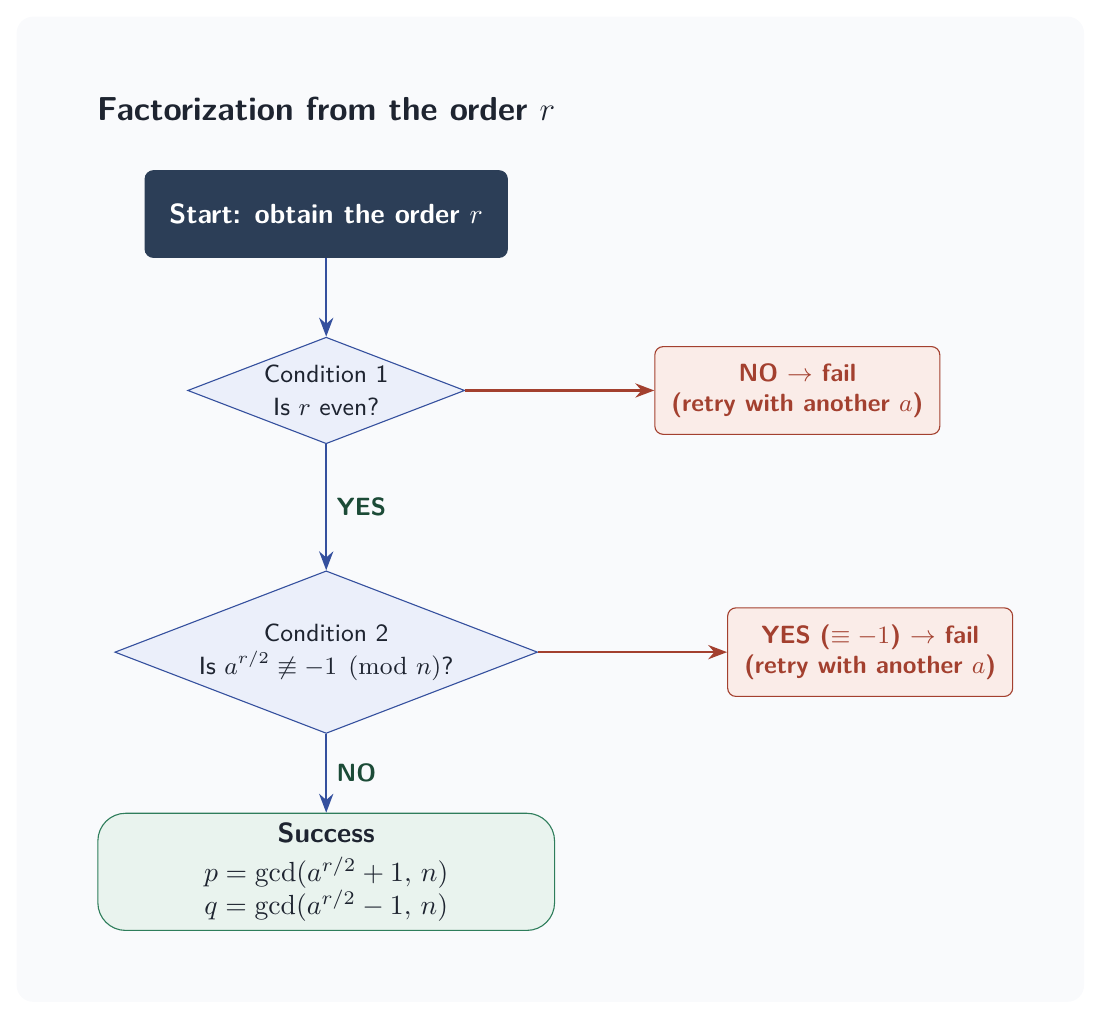

*(The labels in this flowchart are in Japanese; it shows the overall flow described in the cells below: check Condition 1 ($r$ even), check Condition 2 ($a^{r/2} \not\equiv -1 \pmod{n}$), and if both hold obtain the factors via $\gcd$ — otherwise retry with a different $a$.)*

#### **Condition 1: $r$ Must Be Even**



From $a^r \equiv 1 \pmod{n}$ we have $a^r - 1 = kn$ (with $k$ an integer). If $r$ is even, this can be factored as follows.

$$(a^{r/2} + 1)(a^{r/2} - 1) = kn \tag{1.3}$$

If $r$ is odd, this factorization is impossible, so we count it as a failure.



#### **Condition 2: $a^{r/2} \not\equiv -1 \pmod{n}$**



Consider the two factors in Eq. (1.3). We check that the following conditions hold.

- $(a^{r/2} - 1)$ is not a multiple of $n$.\
If $a^{r/2} \equiv 1 \pmod{n}$ held, then $\frac{r}{2}$ would satisfy the defining property of the order, contradicting the definition of the order as the minimum $r$.
- Whether $(a^{r/2} + 1)$ is a multiple of $n$, on the other hand, depends on the value of $a$.\
If $a^{r/2} \equiv -1 \pmod{n}$, then $(a^{r/2} + 1) \equiv 0 \pmod{n}$, so $\gcd(a^{r/2}+1, n) = n$ yields only a trivial value and the attempt fails.

#### **When Both Conditions Hold**



If Conditions 1 and 2 both hold, neither $(a^{r/2}+1)$ nor $(a^{r/2}-1)$ is a multiple of $n$. Their product, however, is $kn$ (a multiple of $n$). The factors $p, q$ of $n = p \times q$ are therefore distributed between $(a^{r/2}+1)$ and $(a^{r/2}-1)$, and can be extracted with $\gcd$ as follows.

$$p = \gcd(a^{r/2} + 1, n), \quad q = \gcd(a^{r/2} - 1, n) \tag{1.4}$$

#### **Implementing the Order-to-Factorization Flow**

Let us now walk through the flow from the order to the prime factors in code.\
We first try the worked example $n=15, a=7$. As found in Section 1.1, the order of $a=7$ is $r=4$ (even), so Condition 1 holds. Moreover, $a=7$ also satisfies Condition 2, so the factorization succeeds.\
— Note, however, that this is only because $a=7$ happens to satisfy both conditions; not every $a$ succeeds. Shortly we will enumerate all $a$ and see how often this succeeds.

> **What to do**\
● Confirm that from the order $r=4$, computing nothing but $\gcd$ yields $15 = 3 \times 5$  
> **Key points**\
● Once the order is known, the prime factors follow from classical computation ($\gcd$) alone. The quantum computer's only job is to find the order

In [6]:
# --- Worked example: check Conditions 1 and 2 and factor with n=15, a=7, r=4 ---
n, a = 15, 7
r = compute_order(a, n)
print(f"=== From the order to the prime factors: n={n}, a={a}, r={r} ===")
print()

# Check Condition 1
print(f"Condition 1: is r={r} even? → {'Yes' if r % 2 == 0 else 'No (failure) '}")
print()

# Check Condition 2
x = pow(a, r // 2, n)
print(f"Condition 2: a^(r/2) = {a}^{r//2} mod {n} = {x}")
print(f"  Is {x} ≡ -1 (mod {n})? → {'Yes (failure) ' if x == n-1 else 'No → condition met'}")
print()

# Both conditions met → compute the prime factors via Eq. (1.4)
print(f"Both conditions hold, so we compute the prime factors via Eq. (1.4):")
print(f"  p = gcd({x}+1, {n}) = gcd({x+1}, {n}) = {gcd(x+1, n)}")
print(f"  q = gcd({x}-1, {n}) = gcd({x-1}, {n}) = {gcd(x-1, n)}")
print()
print(f"Result: {n} = {gcd(x+1, n)} × {gcd(x-1, n)}")
print(f"Factorization succeeded!")

=== From the order to the prime factors: n=15, a=7, r=4 ===

Condition 1: is r=4 even? → Yes

Condition 2: a^(r/2) = 7^2 mod 15 = 4
  Is 4 ≡ -1 (mod 15)? → No → condition met

Both conditions hold, so we compute the prime factors via Eq. (1.4):
  p = gcd(4+1, 15) = gcd(5, 15) = 5
  q = gcd(4-1, 15) = gcd(3, 15) = 3

Result: 15 = 5 × 3
Factorization succeeded!


#### **Wrapping the Order-to-Factorization Flow in a Function**

We now wrap the sequence of steps experienced in the cell above — "Condition 1 (is $r$ even?) → Condition 2 (check that $a^{r/2} \equiv -1$ does not hold) → compute the prime factors from $\gcd$ via Eq. (1.4)" — into a function `factorize_from_order(a, n, r)` for reuse in later cells.

> **What to do**\
● Assuming the order is already known, wrap the checks of Conditions 1 and 2 and the factorization into a function `factorize_from_order(a, n, r)`.\
● Verify it with $a=7$.

| Condition | `status` | `factors` | Meaning |
|------|----------|-----------|------|
| Condition 1 fails ($r$ is odd)  | `'r_odd'` | `None` | The factorization in Eq. (1.3) is impossible |
| Condition 2 fails ($a^{r/2} \equiv -1$)  | `'ar2_eq_minus1'` | `None` | $\gcd$ returns only trivial values |
| Both hold → factorization succeeds | `'success'` | `(p, q)` | $n = p \times q$ |

In [7]:
def factorize_from_order(a: int, n: int, r: int) -> dict:
    """Attempt factorization from the order r (→ Book, "The Order-Finding Problem")

    Returns:
        dict: status ('success', 'r_odd', 'ar2_eq_minus1', 'gcd_trivial') and factors
    """
    # --- Condition 1: is r even? ---
    if r % 2 != 0:
        return {'status': 'r_odd', 'factors': None,
                'detail': f'Condition 1 fails: r={r} is odd → the factorization in Eq. (1.3) is impossible'}

    # --- Condition 2: a^(r/2) ≡ -1 (mod n) must not hold ---
    x = pow(a, r // 2, n)
    if x == n - 1:  # a^(r/2) ≡ -1 (mod n)
        return {'status': 'ar2_eq_minus1', 'factors': None,
                'detail': f'Condition 2 fails: a^(r/2) = {a}^{r//2} mod {n} = {x} ≡ -1 → gcd is trivial'}

    # --- Both conditions hold → compute the prime factors via Eq. (1.4) ---
    p = gcd(x + 1, n)
    q = gcd(x - 1, n)

    # Case where gcd returns only trivial values (1 or n)
    if p in (1, n) or q in (1, n):
        return {'status': 'gcd_trivial', 'factors': None,
                'detail': f'gcd({x}+1, {n})={p}, gcd({x}-1, {n})={q} → only trivial factors'}

    return {'status': 'success', 'factors': (p, q),
            'detail': f'gcd({x}+1, {n})={p}, gcd({x}-1, {n})={q}'}


# --- Verification: confirm we get the same result as the worked example above ---
n, a = 15, 7
r = compute_order(a, n)
result = factorize_from_order(a, n, r)
print(f"factorize_from_order({a}, {n}, {r}) → status={result['status']}, factors={result['factors']}")
print(f"  {result['detail']}")

factorize_from_order(7, 15, 4) → status=success, factors=(5, 3)
  gcd(4+1, 15)=5, gcd(4-1, 15)=3


#### **Q: Does a Randomly Chosen $a$ Actually Succeed?**

Shor's algorithm chooses $a$ at random. If the fraction of successful $a$ were low, many retries would be needed and the algorithm would not be practical. So, for every $a$ in `coprime_a_list` (the list, recorded in Section 1.1, of the $a$ coprime to $n=15$ and their orders), we attempt the factorization and check which $a$ succeed, which fail, and how high the success rate is.

> **Note**\
This code is not a proof of the theory; it is a check that simply looks at the results for the small concrete example $n=15$. That "the fraction of successful $a$ is at least $1/2$" is a mathematically proven theorem (→ Book, "Success Probability and Overall Complexity", Box); here we merely confirm that, for $n=15$, the results are consistent with that theorem.

> **What to do**\
● For each $a$ recorded in Section 1.1, use `factorize_from_order` to run the procedure order $r$ → Condition 1 (is $r$ even?) → Condition 2 (does $a^{r/2} \equiv -1$ fail to hold?) → factorization via $\gcd$, and observe the pattern of successes and failures  
> **Key points**\
● Confirm that, at least in the concrete example $n=15$, the success rate is $\frac{6}{7}$ (strictly speaking, it is known that the success probability is at least $\frac{1}{2}$ → Book, "Success Probability and Overall Complexity", Box)

In [8]:
# --- Try factoring for each coprime a recorded in Section 1.1 ---
n = 15
print(f"=== n={n}: trying order → factorization for each coprime a ===")
print(f"{'a':>3s}  {'r':>3s}  {'even?':>5s}  {'a^(r/2) mod n':>14s}  {'status':>20s}  {'factors':>10s}")
print("-" * 70)

success_count = 0
for a, r in coprime_a_list:
    # factorize_from_order checks Conditions 1 and 2 internally, but returns only the result (status)
    # to show the condition values in the table, we redo the same computation here
    r_even = 'Yes' if r % 2 == 0 else 'No'
    ar2 = str(pow(a, r // 2, n)) if r % 2 == 0 else '---'

    # check Conditions 1 and 2 and perform the factorization with factorize_from_order
    result = factorize_from_order(a, n, r)
    factors_str = f"{result['factors'][0]}×{result['factors'][1]}" if result['factors'] else '---'
    if result['status'] == 'success':
        success_count += 1
    print(f"{a:>3d}  {r:>3d}  {r_even:>5s}  {ar2:>14s}  {result['status']:>20s}  {factors_str:>10s}")

total = len(coprime_a_list)
print()
print(f"Success: {success_count}/{total} = {success_count/total:.0%}")
print(f"→ consistent with the theorem that the success rate is ≥ 1/2")

=== n=15: trying order → factorization for each coprime a ===
  a    r  even?   a^(r/2) mod n                status     factors
----------------------------------------------------------------------
  2    4    Yes               4               success         5×3
  4    2    Yes               4               success         5×3
  7    4    Yes               4               success         5×3
  8    4    Yes               4               success         5×3
 11    2    Yes              11               success         3×5
 13    4    Yes               4               success         5×3
 14    2    Yes              14         ar2_eq_minus1         ---

Success: 6/7 = 86%
→ consistent with the theorem that the success rate is ≥ 1/2


### **1.3 Chapter Summary**


In Chapter 1, we saw firsthand—through the concrete example $n=15$—that Shor's algorithm reduces prime factorization to the problem of "order finding."

- **If we know the order, we can factor**\
If the order $r$ satisfies Conditions 1 and 2, the prime factors are obtained with nothing more than a $\gcd$. With $a=7, r=4$ we derived $15 = 3 \times 5$ (Section 1.2)
- **The success rate is high enough**\
In an exhaustive survey for $n=15$ we observed an $86\%$ success rate. For general $n$, a success probability of $\geq 1/2$ is mathematically guaranteed (→ Book, "Success Probability and Overall Complexity")

→ **The problem of achieving factorization reduces to the question of how to find the order**

(※ All computations up to this point have been purely classical; quantum computers have played no role at all.)

## ⭐ **The Limits of Classical Order Finding — Why Do We Need a Quantum Computer?**



#### **A Toy Demo of Brute-Force Order Finding**

The security of RSA rests on the premise that "factoring a large number cannot be done in realistic time on a classical computer." If order finding could be done quickly, factorization would become possible by the method shown in Chapter 1, and RSA would be broken.

For $n=15$, `compute_order` finished instantly, but that will no longer be the case as $n$ grows. Let us actually run `compute_order` while increasing the bit length of $n$ and measure how the running time changes.

One caveat: `compute_order` is a naive brute-force method that tries $a^k \bmod n$ for $k = 1, 2, \ldots$ in turn, performing $O(r)$ exponentiations for an order $r$. Since $r$ can be about as large as $n$ in the worst case, the computational cost is exponential in $n$ ($O(2^L)$, where $L$ is the bit length of $n$). The results below are merely a demonstration that the problem Shor speeds up quantumly becomes painful very quickly when attacked naively on a classical computer. Note also that individual running times vary greatly with the order of the chosen $a$, so the graph will be jagged.

> **What to do**\
● Measure the running time of the brute-force method (`compute_order`) while increasing the bit length of $n$ from roughly 8 to 27 bits\
→ Output a log-scale plot of bit length vs. running time

※ Above, we used the notation $O(\cdot)$ to express computational cost. $f(n)=O(g(n))$ means that as $n$ grows, the cost grows roughly on the order of $g(n)$. Constant factors and lower-order terms are ignored here.

- Example: $3n^2 + 5n = O(n^2)$  
  When $n$ is large enough, the $n^2$ term dominates, so the constant factor 3 and the lower-order term $5n$ are regarded as inessential and ignored.

- Example: $O(2^L)$ vs. $O(L^3)$  
  $O(2^L)$ grows exponentially: each time $L$ increases by 1, the cost roughly doubles. In contrast, $O(L^3)$ grows polynomially: even if $L$ becomes 10 times larger, the cost grows only by a factor of about 1000.

(For details → Book, "Asymptotic Notation for Complexity", Box)

=== Brute-force order finding (compute_order) ===
  n bits                 n     order r        time
--------------------------------------------------
       8               143          60     0.0000s
       9               493          56     0.0000s
      11              1961         468     0.0001s
      13              6499         528     0.0001s
      15             25283        6240     0.0017s
      17             99973        1552     0.0004s
      19            400649       24960     0.0090s
      21           1590833      397065     0.1934s
      23           6321187        6156     0.0020s


      25          25212949     4200450     2.5704s


      27         100880401     1050624     0.6000s


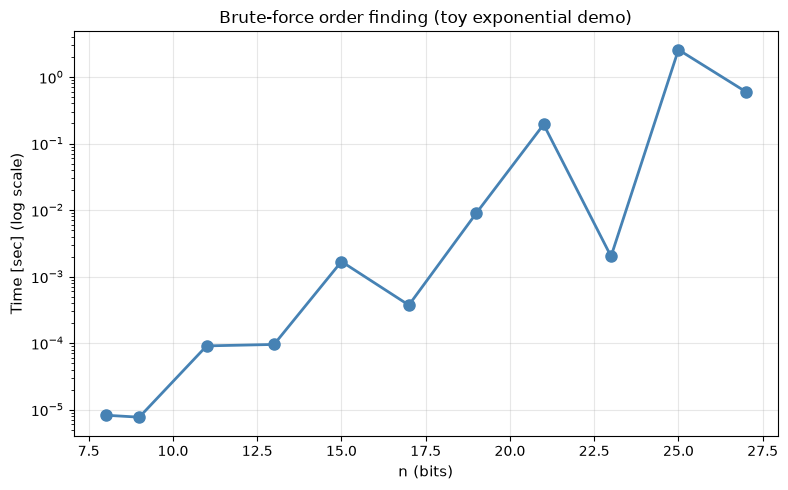

In [9]:
# === Running time of brute-force order finding (toy exponential demo) ===
# See what happens when "order finding" -- the problem Shor speeds up -- is done naively on a classical computer.
# Timings depend on the order of the chosen a, so they vary a lot (the graph will be jagged).

import time
from sympy import nextprime

print("=== Brute-force order finding (compute_order) ===")
print(f"{'n bits':>8s}  {'n':>16s}  {'order r':>10s}  {'time':>10s}")
print("-" * 50)

bit_sizes_brute = []
times_brute = []

for p_bits in range(3, 14):
    p = nextprime(2**p_bits)
    q = nextprime(2**p_bits + 2**p_bits // 2)
    n = p * q
    a = 2
    while gcd(a, n) != 1:
        a += 1

    t1 = time.perf_counter()
    r = compute_order(a, n)
    elapsed = time.perf_counter() - t1

    bit_sizes_brute.append(n.bit_length())
    times_brute.append(elapsed)
    print(f"{n.bit_length():>8d}  {n:>16d}  {r:>10d}  {elapsed:>9.4f}s")

# --- Draw the graph ---
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(bit_sizes_brute, times_brute, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.set_xlabel('n (bits)', fontsize=11)
ax.set_ylabel('Time [sec] (log scale)', fontsize=11)
ax.set_title('Brute-force order finding (toy exponential demo)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

From the graph above, although the individual points scatter depending on the order of the chosen $a$, we confirmed the overall trend: the running time grows exponentially with the bit length.

In addition, at around 27 bits it already takes several seconds, and it clearly comes nowhere near RSA-2048 (2048 bits).
This method is the most naive one, so we cannot conclude from it that classical computation is hopeless. Next, let us look at a practical classical algorithm.

#### **The Scale of the Practical Classical Method (GNFS) — Public Records and the Asymptotic Formula**





The brute force of `compute_order` takes exponential time, and of course practical classical factoring does not use such a method. Practical classical factoring uses the **general number field sieve (GNFS)**. GNFS is the best known classical algorithm, but its implementations are large-scale and sophisticated (dedicated C/C++ tools such as CADO-NFS, and distributed computations on the scale of hundreds to thousands of core-years), so it cannot be casually run inside a Python hands-on.

Therefore, we will instead get a picture of how hard the problem is from the public records of RSA numbers factored on classical computers and from the asymptotic formula.

First, the public records of the RSA Factoring Challenge actually achieved with GNFS are as follows.
| Record | bits | Year | wall-clock | Cost |
|------|-----:|------:|-----------|--------|
| RSA-155 | 512 | 1999 | 7 months | ~8400 MIPS-years |
| RSA-768 | 768 | 2009 | 2+ years | ~1500-2000 core-years |
| RSA-240 | 795 | 2019 | — | ~900-1000 core-years |
| RSA-250 | 829 | 2020 | — | ~2700-2900 core-years |

> **Note**\
> The older records are reported in MIPS-years and the newer ones in core-years, and the accounting also differs slightly from paper to paper. Read this not as a rigorous comparison but as an order-of-magnitude comparison.
>
> - **core-years**\
>The amount of computation done by one CPU core running continuously for one year. For example, 2700 core-years is an amount of computation equivalent to any of "2700 cores for 1 year," "1000 cores for about 2.7 years," or "1 core for 2700 years."
>- **MIPS-years**\
The amount of computation done by running a 1 MIPS (Million Instructions Per Second) machine for one year. A benchmark unit from an older generation.

The next cell then uses the asymptotic work factor of GNFS to estimate how much harder RSA-1024 / RSA-2048 are relative to RSA-250. Here, the "asymptotic work factor" is a rough estimate of the computation required as the input size $N$ grows — an order-of-magnitude indicator that ignores constant factors and the like. The asymptotic work factor of GNFS is given by the following formula.

$$
L_N\!\left[\tfrac{1}{3},\, c\right] \;=\; \exp\!\left(c \cdot (\ln N)^{1/3} \cdot (\ln \ln N)^{2/3}\right) \qquad \bigl(c = (64/9)^{1/3} \approx 1.923,\; N\text{ is the integer being factored}\bigr)
$$

As $N$ grows, this function $L_N$ increases **more slowly than an exponential but faster than any polynomial** — the typical shape of "**subexponential time**" (for details, see Book, "Comparison with Classical Algorithms").

In [10]:
# === Public GNFS records (order-of-magnitude comparison) ===
# Note:
#   * older records are reported in MIPS-years, newer ones in core-years
#   * read as an order-of-magnitude comparison, not a rigorous one
records = [
    ('RSA-155', 512, 1999, '7 months',  '~8400 MIPS-years'),
    ('RSA-768', 768, 2009, '2+ years',  '~1500-2000 core-years'),
    ('RSA-240', 795, 2019, '-',         '~900-1000 core-years'),
    ('RSA-250', 829, 2020, '-',         '~2700-2900 core-years'),
]

print('=== Public records achieved with GNFS (RSA Factoring Challenge) ===')
print(f"{'name':>8s}  {'bits':>5s}  {'year':>5s}  {'wall-clock':>11s}  {'cost':>24s}")
print('-' * 65)
for name, bits, year, wall, cost in records:
    print(f'{name:>8s}  {bits:>5d}  {year:>5d}  {wall:>11s}  {cost:>24s}')

# === GNFS complexity for RSA-2048 (asymptotic work factor) ===
import math

def gnfs_work(bits: int) -> float:
    """Asymptotic GNFS work factor: L_N[1/3, (64/9)^(1/3)]"""
    lnN = bits * math.log(2)
    c = (64 / 9) ** (1 / 3)
    return math.exp(c * lnN ** (1 / 3) * math.log(lnN) ** (2 / 3))

w_829  = gnfs_work(829)   # RSA-250
w_1024 = gnfs_work(1024)
w_2048 = gnfs_work(2048)

ratio_1024 = w_1024 / w_829
ratio_2048 = w_2048 / w_829

print('\n=== Rough extrapolation from the GNFS asymptotic formula ===')
print(f'Asymptotic GNFS work factor for RSA-2048: {w_2048:.2e}')
print(f'RSA-1024 is about {ratio_1024:.2e} times harder than RSA-250')
print(f'RSA-2048 is about {ratio_2048:.2e} times harder than RSA-250')

base = 2700  # rough total core-years for RSA-250
print(f'RSA-1024 ≈ {base * ratio_1024:.2e} core-years (relative to RSA-250)')
print(f'RSA-2048 ≈ {base * ratio_2048:.2e} core-years (relative to RSA-250)')

=== Public records achieved with GNFS (RSA Factoring Challenge) ===
    name   bits   year   wall-clock                      cost
-----------------------------------------------------------------
 RSA-155    512   1999     7 months          ~8400 MIPS-years
 RSA-768    768   2009     2+ years     ~1500-2000 core-years
 RSA-240    795   2019            -      ~900-1000 core-years
 RSA-250    829   2020            -     ~2700-2900 core-years

=== Rough extrapolation from the GNFS asymptotic formula ===
Asymptotic GNFS work factor for RSA-2048: 1.53e+35
RSA-1024 is about 2.00e+02 times harder than RSA-250
RSA-2048 is about 2.33e+11 times harder than RSA-250
RSA-1024 ≈ 5.40e+05 core-years (relative to RSA-250)
RSA-2048 ≈ 6.29e+14 core-years (relative to RSA-250)


Above, the extrapolation is anchored to RSA-250 (about 2700 core-years), the largest record actually factored.
Taking the 2700 core-years of RSA-250 as the baseline, solving RSA-2048 on a single core would require time on an order far exceeding the age of the universe (~10¹⁰ years); even pooling today's fleets of supercomputers for parallel computation leaves it effectively out of reach.

That said, this is a rough extrapolation based on the GNFS asymptotic formula, and the farther we extrapolate, the less reliable it becomes. Algorithmic improvements and parallelization efficiency also play a role, so it should be read as an order-of-magnitude picture.

By contrast, Shor's algorithm runs in polynomial time in the input bit length $L$. This subexponential-vs-polynomial gap is precisely the basis for the claim that a quantum computer would break RSA.

---

## **2. Running the Circuit: Shor's Algorithm in Action**



### **2.1 Goal and Contents of This Chapter**

In Chapter 1 we confirmed that knowing the order is enough to factor, saw that naive classical order finding quickly becomes prohibitively expensive, and saw that the practical classical methods improve on it dramatically through sieve-based techniques. Even so, the best classical method runs in subexponential time and cannot reach RSA-2048.

Shor's algorithm accomplishes this order finding in polynomial time via quantum phase estimation (QPE) (→ Book, "Quantum Phase Estimation", "Shor's Algorithm"). Here we leave the theoretical details to the Book and concentrate on building the circuit, running it, and seeing the results for yourself.

There are several ways to implement the full Shor algorithm as a quantum circuit. This hands-on builds the circuit using the Fourier-space arithmetic of Beauregard (2003) (modular multiplication based on the Draper adder).
The basic structure — building modular multiplication out of adders — is not a simplification made for teaching purposes. At the practical scale, further-optimized schemes such as Gidney-Ekerå (2021) are being considered, but the basic structure is the same. The scheme adopted here requires few qubits, so it can be run on a simulator even for $n=15$.





The flow of Shor's algorithm follows the basic framework of computation on a quantum computer, shown below.

- **1. Prepare the initial state**\
Set the qubits to a prescribed state
- **2. Apply quantum gates**\
Apply unitary operators in sequence to transform the state
- **3. Measurement + classical computation**\
Measure the qubits and, based on the outcome, obtain the desired answer with a classical computation

Prime factorization is reduced to the problem of "order finding"; the order is obtained with a quantum circuit, and the factorization is then completed classically. In this hands-on, we will experience this flow one step at a time.

Following this framework, we now build the quantum circuit for Shor's algorithm in the following six steps.

| Step | What to Do | Where in the Book |
|---------|---------|----------|
| **1. Prepare the initial state** | Control register $\lvert 0\rangle^{\otimes M}$ + target register $\lvert 1\rangle$ | → Book, "The Steps of Shor's Algorithm", Step 1 |
| **2. Hadamard gates** | Put the control register into a superposition | → Book, "The Steps of Shor's Algorithm", Step 2 |
| **3. Controlled modular exponentiation** | Apply "multiply by $a$ mod $n$" in a controlled way with quantum gates ← **the Shor-specific part inside QPE** | → Book, "The Steps of Shor's Algorithm", Step 3 |
| **4. Inverse QFT** | Convert the phase information into a measurable form | → Book, "The Steps of Shor's Algorithm", Step 4 |
| **5. Measurement** | Measure the control register to obtain the value $z$ | → Book, "The Steps of Shor's Algorithm", Step 5 |
| **6. Continued fractions → factorization** | Recover the order $r$ from $z$ and find the prime factors by the method of Chapter 1 | → Book, "The Steps of Shor's Algorithm", Steps 5–6 |

### **2.2 Choosing the Composite $n$, a Coprime $a$, and the Register Layout**



As a worked example, this hands-on builds the circuit for $n=15, a=7$.

※ The code built below is not specific to $n=15$: it is a general-purpose construction that works unchanged for other numbers if you change $n$ (a small odd composite) and $a$ (with $\gcd(a, n)=1$). As stated in the design policy at the beginning, unlike a toy implementation optimized for $n=15$ (a compiled, special-cased version), the circuit structure itself is designed to take $n$ as a parameter.


The implementation in this hands-on uses the following four registers (groups of qubits with specific roles). Every register size is determined automatically from $N$, for a total of $4N+2$ qubits.

Note that Beauregard's original paper also proposes an optimized construction ($2N+3$ qubits) that keeps the qubit count down at the cost of heavy use of mid-circuit measurement and classical feedback. This hands-on gives priority to circuit readability and adopts the more standard, easier-to-understand construction. For details, see the Book, "Implementation".

| Register | Size | How It Is Determined | For $n=15$ |
|---------|-------|--------|-------------|
| `ctrl` (control)  | $M = 2N$ | QPE precision (→ Book, "The Steps of Shor's Algorithm")  | $2 \times 4 = 8$ qubits |
| `x` (target)  | $N$ (the number of bits needed to represent $n$ in binary)  | Determined by the size of $n$ | $4$ qubits |
| `acc` (addition)  | $N + 1$ | Used for Fourier-space addition | $5$ qubits |
| `anc` (ancilla)  | $1$ | For the comparison in modular addition | $1$ qubit |
| **Total** | **$4N + 2$** | | **$18$ qubits** |






Even for a number as small as $n=15$, 18 qubits are needed.

The following code sets these parameters.

> **What to do**\
● Set $n=15$ and determine the register sizes according to this implementation's layout.  
>  ctrl: `M`=8, x: `N`=4, acc: `N_acc`=5, anc: 1

In [11]:
# --- Parameter setup ---
import time

n_number = 15
a = 7
assert gcd(a, n_number) == 1, f"a={a} and n={n_number} are not coprime (gcd={gcd(a, n_number)})"
N = ceil(log2(n_number))   # 4
M = 2 * N                  # 8
r_true = compute_order(a, n_number)  # find the order classically as in Chapter 1 (used to check the answer after running the circuit)
shots = 4096

print(f"=== Parameters ===")
print(f"n = {n_number} (number to factor)")
print(f"a = {a} (base)")
print(f"N = {N} (number of qubits in the target register: ceil(log2({n_number})))")
print(f"M = {M} (number of qubits in the control register: 2N)")
print()

# Register layout
N_acc = N + 1
print(f"=== Register layout ===")
print(f"  ctrl:  {M} qubits  (QPE control qubits)")
print(f"  x:     {N} qubits  (target, initialized to |1⟩)")
print(f"  acc:   {N_acc} qubits  (addition register for the Beauregard scheme)")
print(f"  anc:   1 qubit   (ancilla for modular addition)")
print(f"  total: {M + N + N_acc + 1} qubits")

=== Parameters ===
n = 15 (number to factor)
a = 7 (base)
N = 4 (number of qubits in the target register: ceil(log2(15)))
M = 8 (number of qubits in the control register: 2N)

=== Register layout ===
  ctrl:  8 qubits  (QPE control qubits)
  x:     4 qubits  (target, initialized to |1⟩)
  acc:   5 qubits  (addition register for the Beauregard scheme)
  anc:   1 qubit   (ancilla for modular addition)
  total: 18 qubits


### **2.3 Step 1: Preparing the Initial State**



→ Book, "The Steps of Shor's Algorithm", Step 1

As stated at the outset, a quantum computation proceeds in three steps: "(1) prepare the initial state → (2) apply quantum gates → (3) measure + classical computation." From here on, we build up the circuit following this flow.

First, for (1) preparing the initial state, we set the control register to $|0\rangle^{\otimes M}$ and the target register to $|1\rangle$.

Here, $|1\rangle$ means "the state $|00\ldots01\rangle$ that represents the integer 1 as an $N$-bit binary number" (→ Book, "The Steps of Shor's Algorithm", Step 1). We set the target register to $|1\rangle$ in order to sample all eigenstates of the modular multiplication operator with equal probability (→ Book, "The Modular Multiplication Operator").


As an implementation-specific detail, Qiskit automatically initializes registers to $|0\rangle$, so we create $|1\rangle$ by applying an X gate (the gate that flips $|0\rangle$ and $|1\rangle$) to the least significant bit of the target register.


**Overall state after Step 1 (→ Book, "The Steps of Shor's Algorithm", equation)**

$$|\psi_1\rangle = |0\rangle^{\otimes M}_{\mathcal{M}} \otimes |1\rangle_{\mathcal{N}}$$

> **What to do**\
● Prepare the initial state $|0\rangle^{\otimes M}_{\mathcal{M}} \otimes |1\rangle_{\mathcal{N}}$. In this hands-on, we build the quantum circuit using the Qiskit API.\
● Create four registers with `QuantumRegister` (the class that defines a group of qubits) and combine them into a `QuantumCircuit` (the class that creates a quantum circuit). Apply an X gate to the target register to set it from $|0\rangle \to |1\rangle$.\
> **Key points**\
● In Qiskit every qubit is initialized to $|0\rangle$, so we apply an X gate to the least significant bit of the target register to turn $|00\ldots0\rangle$ → $|00\ldots1\rangle = |1\rangle$.

In [12]:
# --- Step 1: Preparing the initial state ---
from qiskit.quantum_info import Statevector  # class for obtaining the quantum state of a circuit

# --- Define the four registers ---
ctrl = QuantumRegister(M, name='ctrl')    # control register: M=8 qubits
x = QuantumRegister(N, name='x')          # target register: N=4 qubits
acc = QuantumRegister(N + 1, name='acc')  # addition register: N+1=5 qubits
anc = QuantumRegister(1, name='anc')      # auxiliary register: 1 qubit (fixed)
c = ClassicalRegister(M, name='meas')     # classical register: M=8 bits to store the measurement results (not qubits)


# Let's see what these objects look like
print("=== Register contents ===")
print(f"ctrl: {ctrl}  → {ctrl.size} qubits, name '{ctrl.name}'")
print(f"x:    {x}  → {x.size} qubits, name '{x.name}'")
print(f"acc:  {acc}  → {acc.size} qubits, name '{acc.name}'")
print(f"anc:  {anc}  → {anc.size} qubit, name '{anc.name}'")
print(f"c:    {c}  → {c.size} classical bits, name '{c.name}'")
print()
print(f"Total qubits: {ctrl.size + x.size + acc.size + anc.size}")
print(f"Total classical bits: {c.size}")



=== Register contents ===
ctrl: QuantumRegister(8, 'ctrl')  → 8 qubits, name 'ctrl'
x:    QuantumRegister(4, 'x')  → 4 qubits, name 'x'
acc:  QuantumRegister(5, 'acc')  → 5 qubits, name 'acc'
anc:  QuantumRegister(1, 'anc')  → 1 qubit, name 'anc'
c:    ClassicalRegister(8, 'meas')  → 8 classical bits, name 'meas'

Total qubits: 18
Total classical bits: 8


A `QuantumRegister` is a Qiskit object representing "a named collection of qubits." At this point it is not yet part of any quantum circuit; it exists only as a building block.

We have now defined four quantum registers and one classical register and checked their contents.
The role of each register is briefly summarized below.

```
Structure of the final circuit

  ctrl (8 qubits)  ─── H ─── controlled-U ─── IQFT ─── measure → c (8 classical bits)
  x    (4 qubits)  ─── X ─── target of U
  acc  (5 qubits)  ─── (for Beauregard-style addition)
  anc  (1 qubit)   ─── (for the sign test in modular addition)
```

In the next cell, we pass these registers to `QuantumCircuit` to create the circuit object. In Qiskit, the initial state is always fixed at $|0\rangle$.

Type: QuantumCircuit
Number of qubits: 18
Number of classical bits: 8
Gate count: 0 (nothing added yet)

Empty circuit:


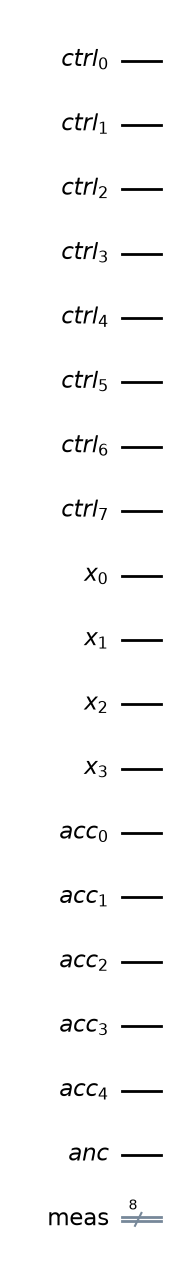

In [13]:
# --- Combine the registers into a quantum circuit ---
# Passing the registers to QuantumCircuit creates a circuit object
# At this point every qubit is |0⟩ and no gates have been added
qc = QuantumCircuit(ctrl, x, acc, anc, c)

# Check what kind of object qc is
print(f"Type: {type(qc).__name__}")
print(f"Number of qubits: {qc.num_qubits}")
print(f"Number of classical bits: {qc.num_clbits}")
print(f"Gate count: {qc.size()} (nothing added yet)")
print()

# Display the empty circuit (all qubits |0⟩, no gates)
print("Empty circuit:")
display(qc.draw('mpl'))

# Save the empty circuit (so that re-running the Step 1 cells stays safe)
qc_step0 = qc.copy()

The circuit has been created, but the qubits are in the $|0\rangle$ state and there are no gates yet.

Since we want to prepare the state $|\psi_1\rangle = |0\rangle^{\otimes M}_{\mathcal{M}} \otimes |1\rangle_{\mathcal{N}}$, we use the `.x()` method to add an X gate (`qc.x(x[0])`) on the least significant bit of the target register, taking $|0\rangle \to |1\rangle$.

Step 1 complete: added the X gate to prepare the initial state
  Gate count: 1 (one X gate added)

Circuit after adding the X gate:


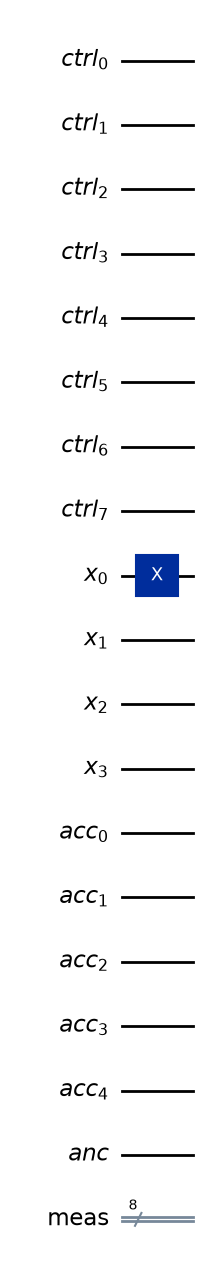

In [14]:
# --- Apply an X gate to the least significant bit of the target register ---
# Reset to the freshly created circuit (so that re-running this cell does not stack extra X gates)
qc = qc_step0.copy()
# Turn |0000⟩ → |0001⟩ = |1⟩ (the integer 1 as a 4-bit binary number)
qc.x(x[0])

print("Step 1 complete: added the X gate to prepare the initial state")
print(f"  Gate count: {qc.size()} (one X gate added)")
print()
print("Circuit after adding the X gate:")
display(qc.draw('mpl'))

# Save the circuit at the end of Step 1 (so later steps can be re-run safely)
qc_step1 = qc.copy()

We have added the X gate to the circuit. Let us verify that the target register really is now $|1\rangle$.

Qiskit's `Statevector.from_instruction()` computes the statevector of a quantum circuit (the amplitude of each computational basis state $|0\rangle, |1\rangle, \ldots$). Looking only at the components with nonzero amplitude tells us which state the circuit is in.

> **About statevector indices**\
> The integer displayed (e.g., the `256` in $|256\rangle$) is the integer value obtained by reading all 18 qubits as a binary number. Qiskit lines up the qubits in the order the registers were added (`ctrl` → `x` → `acc` → `anc`), treating the least significant bit as bit 0, with bit numbers increasing toward more significant bits.
> - bits 0–7: the `ctrl` register (8 bits)
> - bits 8–11: the `x` register (4 bits)
> - bits 12–16: the `acc` register (5 bits)
> - bit 17: the `anc` register (1 bit)
>
> In this case, we applied the X gate to the least significant bit of the target `x` (= bit 8 of the whole system). Concretely, writing out the bit values of each register (with the most significant bit 17 on the left and the least significant bit 0 on the right) gives the following.
>
> ```
> anc | acc   | x    | ctrl
> ----+-------+------+----------
>  0  | 00000 | 0001 | 00000000
> ```
>
> Reading the concatenated binary string `000000010000000000` as an integer: only `bit 8` is 1, so the value is $2^8 = 256$. That is, ideally, only the state $|256\rangle$ appears, with probability $1$.

In [15]:
# --- Verify the initial state with the statevector ---
# Build a circuit without the classical register (Statevector handles qubits only)
qc_no_meas = qc_step1.remove_final_measurements(inplace=False)

# Get the statevector after running the circuit
sv = Statevector.from_instruction(qc_no_meas)
print(sv)

# Show only the components with nonzero amplitude
print("Checking the quantum state (only states with nonzero amplitude shown):")
for i, amp in enumerate(sv):
    if abs(amp) > 1e-10:
        print(f"  amplitude of |{i}⟩ = {amp.real:.4f}  → probability {abs(amp)**2:.4f}")

Statevector([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2))
Checking the quantum state (only states with nonzero amplitude shown):
  amplitude of |256⟩ = 1.0000  → probability 1.0000


### **2.4 Step 2: Hadamard Gates on the Control Register**



→ Book, "The Steps of Shor's Algorithm", Step 2

We apply the Hadamard gate $H$ to every qubit of the control register, transforming $|0\rangle^{\otimes M}$ into the uniform superposition of all computational basis states, $\frac{1}{\sqrt{2^M}} \sum_{z=0}^{2^M-1} |z\rangle$.

**The overall state after Step 2** is as follows.

$$|\psi_2\rangle = \frac{1}{\sqrt{2^M}} \sum_{z=0}^{2^M-1} |z\rangle_{\mathcal{M}} \otimes |1\rangle_{\mathcal{N}}$$

> **What to do**\
● Apply the Hadamard gate $H$ to all $M=8$ qubits of the control register.\
In Qiskit, `qc.h(ctrl)` applies it to the whole control register at once.\
> **Key points**\
● $H$ is the gate that transforms $|0\rangle$ into $(|0\rangle + |1\rangle)/\sqrt{2}$; applying it to all 8 qubits produces a uniform superposition of $2^8 = 256$ states

> ※ **Superposition alone does not speed up computation** (→ Book, "The Steps of Shor's Algorithm", Step 3) \
Looking at the superposition formula, it may seem that "$2^M$ computations are being executed simultaneously," but a measurement yields only a single value. This is fundamentally different from parallel computation in the classical sense. The reason quantum computation is fast — as we will see in practice below — is not the superposition itself, but the fact that quantum interference (the inverse QFT) amplifies the probability of the correct answers (the values $z$ corresponding to the phases $\frac{s}{r}$) and cancels out the rest. Only the combination of this interference and the continued-fraction expansion lets us extract the order $r$.

Step 2 complete: applied Hadamard gates to the control register
  Number of Hadamard gates: 8
  Total gate count of the current circuit: 9



Checking the statevector:
  Number of components with nonzero amplitude: 256 (correct if it equals 2^8 = 256)
  Probability of each component: 0.003906
  All equal probability: True
  → the control register is in a uniform superposition of 256 states

Current circuit:


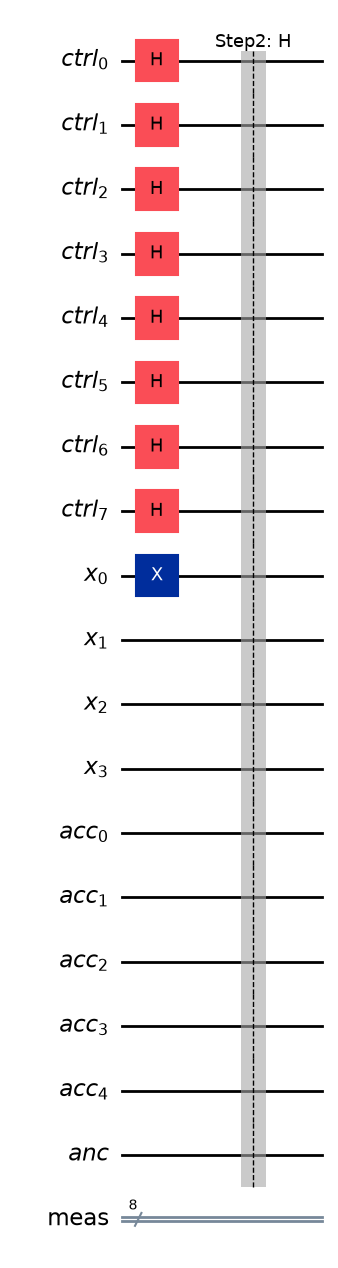

In [16]:
# --- Step 2: Hadamard gates on the control register ---

# Copy the circuit from the end of Step 1 (so that re-running this cell does not stack extra H gates)
qc = qc_step1.copy()

# Apply the Hadamard gate H to all 8 qubits of the ctrl register
qc.h(ctrl)

# barrier: a divider in the circuit diagram; purely for readability, it does not affect the quantum state
qc.barrier(label='Step2: H')

print("Step 2 complete: applied Hadamard gates to the control register")
print(f"  Number of Hadamard gates: {M}")
print(f"  Total gate count of the current circuit: {qc.size()}")
print()

# --- Check the statevector the same way as in Step 1 ---
qc_no_meas = qc.remove_final_measurements(inplace=False)  # remove the classical register
sv = Statevector.from_instruction(qc_no_meas)               # get the statevector

# Compute each component's probability (squared absolute value of the amplitude)
probs = [abs(amp)**2 for amp in sv]

# Count the nonzero components
n_nonzero = sum(1 for p in probs if p > 1e-10)

# Check whether all nonzero components have the same probability
nonzero_probs = [p for p in probs if p > 1e-10]
all_equal = all(abs(p - nonzero_probs[0]) < 1e-10 for p in nonzero_probs)

print(f"Checking the statevector:")
print(f"  Number of components with nonzero amplitude: {n_nonzero} (correct if it equals 2^{M} = {2**M})")
print(f"  Probability of each component: {nonzero_probs[0]:.6f}")
print(f"  All equal probability: {all_equal}")
print(f"  → the control register is in a uniform superposition of {n_nonzero} states")

print()
print("Current circuit:")
display(qc.draw('mpl'))

# Save the circuit at the end of Step 2
qc_step2 = qc.copy()

### **2.5 Preparing for Step 3: Building Controlled Modular Multiplication from Adders**



#### **The Gates Added in Step 3**



Through Step 2, we have built a circuit in the following state.

$$|\psi_2\rangle = \frac{1}{\sqrt{2^M}} \sum_{z=0}^{2^M-1} |z\rangle_{\mathcal{M}} \otimes |1\rangle_{\mathcal{N}}$$

In Step 3, we want to add "controlled modular exponentiation gates" to this circuit to create the following state.

$$|\psi_3\rangle = \frac{1}{\sqrt{2^M}} \sum_{z=0}^{2^M-1} |z\rangle_{\mathcal{M}} \otimes U_{a,n}^z |1\rangle_{\mathcal{N}} = \frac{1}{\sqrt{2^M}} \sum_{z=0}^{2^M-1} |z\rangle_{\mathcal{M}} \otimes |a^z \bmod n\rangle_{\mathcal{N}}$$

That is, we need gates that apply $U_{a,n}^{2^k}$ to the target according to each control qubit $k$, producing $a^z \bmod n$.

Qiskit does provide general multiplication circuits (such as `RGQFTMultiplier`), but it does not provide a standard gate that directly performs the "modular multiplication by a constant $a$, $|x\rangle \to |ax \bmod n\rangle$" that Shor's algorithm requires. We therefore have to build it ourselves from more basic components.

> For the part that "applies $U_{a,n}^{2^k}$ to the target register only when control qubit $k$ is $|1\rangle$," we use the controlled-gate machinery that Qiskit provides (`cp`, `PhaseGate.control()`, and so on). (On real hardware this uses physical interactions between two qubits and the implementation is involved, but for this material it is enough to know how to use it at the API level.)



#### **How Modular Multiplication Decomposes**



Implementing modular multiplication in one go may feel daunting, but breaking it down into stages makes the path clear.

>**(1) Modular multiplication = repeated modular addition**

Consider the multiplication $c \times x$ of a constant $c$ and $x$. Expanding $x$ as an $N$-bit binary number $x = (x_{N-1} \cdots x_1 x_0)_2 = \sum_k x_k \cdot 2^k$ (each $x_k$ is 0 or 1), we can write the product as follows.
$$c \times x = c \cdot x_0 + (2c) \cdot x_1 + (4c) \cdot x_2 + \cdots = \sum_k (c \cdot 2^k) \cdot x_k$$
In other words, multiplication can be realized by repeatedly deciding "whether to add $c \cdot 2^k$, depending on bit $x_k$ of $x$."\
For example, with $c=7, x=5=(0101)_2$ we get $7 \times 5 = 7 \cdot 1 + 14 \cdot 0 + 28 \cdot 1 + 56 \cdot 0 = 35$.\
Performing each addition in the expansion above $\bmod n$ turns this into modular multiplication. The part that "performs the addition $\bmod n$" is the modular adder.


>**(2) Modular addition = addition + the mod step**

Modular addition $(b + a) \bmod n$ can be realized by first adding $a$ and then subtracting $n$ back off if the result exceeds $n$. Since "subtracting $n$" is the same as "adding $-n$," this too can be done with an adder.


Therefore, **as long as we can implement an adder, we can construct modular addition via (2) and then modular multiplication via (1)**, in that order.

>**Strategy for building modular multiplication**

In what follows, we proceed in the order **addition → modular addition → modular multiplication**, implementing and verifying one basic component at a time. The functions defined here are used as-is inside the final Shor circuit (Step 3).

| Level | What to do | Function to implement |
|-------|---------|------------|
| Level 0 | Addition (in Fourier space) | `phi_add()` |
| Level 1 | Modular addition (with $\bmod n$) | `cc_phi_add_mod()` |
| Level 2 | Controlled modular multiplication | `c_mult_mod()` |


#### **Level 0: Constant Addition in Fourier Space (the Draper Adder)**

Let us begin by implementing the adder.\
There are several ways to realize addition with quantum gates (carry-propagation adders, among others), but the Beauregard construction adopts the **Draper adder**. Because the Draper adder performs addition as phase rotations in Fourier space, it needs no ancilla qubits to store carries, which keeps down the total qubit count of the circuit.


##### **What Is the "Phase" of a Qubit?**


To understand the idea behind the Draper adder, we first need to pin down what "phase" refers to.

A general single-qubit state can be written $\alpha|0\rangle + \beta|1\rangle$ ($|\alpha|^2+|\beta|^2=1$), but in the post-QFT states we deal with below, each qubit takes the equal-amplitude form $\frac{1}{\sqrt{2}}\bigl(|0\rangle + e^{i\varphi}|1\rangle\bigr)$. This $\varphi$ is called the relative phase.

Below, we will see how the QFT encodes the value $b$ stored in a register into these phases, and how the Draper adder realizes addition by manipulating them.


##### **A Property of the QFT: The Stored Value Is Distributed into Phases**


The QFTGate (quantum Fourier transform) is an operation that transforms a computational basis state $|b\rangle$ (the value $b$ stored in the register) into a different basis (for details, see the Book, "Quantum Phase Estimation"). Here we cover only the properties needed to understand the Draper adder.

The definition of the QFT is as follows (→ Book, "Quantum Phase Estimation").

$$U_{\text{QFT}}|b\rangle = \frac{1}{\sqrt{2^N}} \sum_{z=0}^{2^N-1} e^{2\pi i b \frac{z}{2^N}} |z\rangle$$

The QFT has an inverse (IQFT: the inverse quantum Fourier transform), which brings the information encoded in the phases back to the original computational basis.\
(The Draper adder uses this round trip: QFT → phase manipulation → IQFT.)

The expression above can be rewritten as a tensor product over the individual qubits, as follows.

$$U_{\text{QFT}}|b\rangle = \frac{1}{\sqrt{2^N}} \bigotimes_{k=0}^{N-1} \left( |0\rangle + e^{i\varphi_k} |1\rangle \right), \quad \varphi_k = \frac{2\pi \cdot b}{2^{N-k}}$$

In other words, the value $b$ stored in the register (e.g., $b=5$ for $|0101\rangle$) is distributed by the QFT into the phase $\varphi_k$ of each qubit. The Draper adder exploits this property to realize addition just by rotating phases.




##### **The Draper Adder: Addition by Rotating Phases**


If $b$ is encoded in the phases $\varphi_k$ of the post-QFT state, then after rotating each $\varphi_k$ slightly to the phase corresponding to $b+a$, **returning to the computational basis with the IQFT (the inverse quantum Fourier transform, i.e., the inverse of the QFT) yields $|b+a\rangle$**. That is, the Draper adder realizes addition through the round trip QFT → phase rotation → IQFT. This is the heart of the Draper adder, and because no ancilla qubits are needed, it keeps down the total qubit count of the circuit.


Now suppose we want to add a constant $a$ to the value $b$ stored in the register, obtaining $b + a$. Since the post-QFT phases are $\varphi_k = 2\pi b / 2^{N-k}$, to go from $b \to b+a$ we simply rotate the phases as follows.

$$\varphi_k \;\to\; \varphi_k + \underbrace{\frac{2\pi \cdot a}{2^{N-k}}}_{\theta_k} = \frac{2\pi \cdot b}{2^{N-k}} + \frac{2\pi \cdot a}{2^{N-k}} = \frac{2\pi \cdot (b+a)}{2^{N-k}}$$

This additional rotation $\theta_k$ is determined by $a$ alone and does not depend on $b$.



##### **Implementation: Turning Phase-Rotation Addition into Functions**


To summarize, addition with the Draper adder follows the flow "transform into Fourier space with the QFT → rotate the phases by $\theta_k$ → transform back with the IQFT."

$$|b\rangle \xrightarrow{\text{QFT}} \bigotimes_k (|0\rangle + e^{i\varphi_k}|1\rangle) \xrightarrow{P(\theta_k)} \bigotimes_k (|0\rangle + e^{i(\varphi_k + \theta_k)}|1\rangle) \xrightarrow{\text{IQFT}} |b + a\rangle$$

Of the pieces in the expression above, the QFT and the IQFT are already provided by Qiskit (the `QFTGate` class). What we have to implement ourselves is the middle piece: **the part that rotates the phases by $\theta_k$**. This requires writing the following two functions.

1. **Compute $\theta_k$** (determine how far to rotate the phases from the addend $a$)\
→ the `get_angles` function
2. **Rotate the phases by $\theta_k$** (add phase gates $P(\theta_k)$ to the circuit)\
→ the `phi_add` function

| Function | Input | Output | What it does |
|------|------|------|--------------|
| `get_angles(a, N)` | the addend $a$, the number of bits $N$ | the list of per-bit rotation angles $[\theta_0, \theta_1, \ldots, \theta_{N-1}]$ | computes $\theta_k = 2\pi \cdot a / 2^{N-k}$ from the formula above |
| `phi_add(qc, angles, qubits)` | the quantum circuit `qc`, the angle list `angles`, the target qubits | (adds phase gates to the circuit) | applies $P(\theta_k)$ to each bit, i.e., performs $\varphi_k \to \varphi_k + \theta_k$ |

In the next cell we define these two functions and check what values of $\theta_k$ `get_angles` returns. After that, we assemble the full QFT → `phi_add` → IQFT sequence as a circuit and verify, over all input patterns, that it really performs addition.

> **What to do**\
● Define a function that computes the phase-rotation angle $\theta_k$ for each bit from the addend $a$ → `get_angles(a, N)`\
● Define a function that adds the computed $\theta_k$ to the circuit as Qiskit phase gates `P(θ)` (a gate that rotates a qubit's phase by $\theta$) → `phi_add(qc, angles, qubits)`\
● Run `get_angles` with $a=3, N=4$ and check the value of each $\theta_k$


In [17]:
# --- get_angles: compute θ_k = 2π·a / 2^(N-k) ---
def get_angles(a, n_bits):
    """Compute and return the phase-rotation angle θ_k = 2π·a / 2^(N-k) for each bit k"""
    angles = np.zeros(n_bits)
    for k in range(n_bits):
        angles[k] = 2 * np.pi * a / (2 ** (n_bits - k))
    return angles


# --- phi_add: apply phase gates with the computed θ_k ---
def phi_add(qc, angles, target_qubits):
    """Constant addition in Fourier space: apply P(θ_k) to each bit"""
    for i in range(len(target_qubits)):
        if abs(angles[i]) > 1e-15:
            qc.p(angles[i], target_qubits[i])


# --- Verifying get_angles (with values different from the main run) ---
demo_bits = 3   # assume a 3-bit register
demo_a = 5      # the case of adding the constant 5
demo_angles = get_angles(demo_a, demo_bits)

print(f"Verification: result of get_angles(a={demo_a}, n_bits={demo_bits}):")
print()
for k in range(demo_bits):
    print(f"  k={k}: θ_{k} = 2π·{demo_a}/2^{demo_bits-k} = {demo_angles[k]:.4f} rad")
print()
print("phi_add is the function that applies P(θ_k) to each bit with these angles.")

Verification: result of get_angles(a=5, n_bits=3):

  k=0: θ_0 = 2π·5/2^3 = 3.9270 rad
  k=1: θ_1 = 2π·5/2^2 = 7.8540 rad
  k=2: θ_2 = 2π·5/2^1 = 15.7080 rad

phi_add is the function that applies P(θ_k) to each bit with these angles.


##### **Building and Running the Draper Adder Circuit**

Using `get_angles` and `phi_add`, let us actually build an addition circuit.

$|b\rangle \xrightarrow{QFT} \xrightarrow{phi\_add(a)} \xrightarrow{IQFT} |b+a\rangle$

We first check the circuit diagram with the concrete example $b=5, a=3$, and then verify all patterns.

> **What to do**\
● Set the value $b$ in a 4-bit register, run the QFT → `phi_add`($a=3$) → IQFT circuit, and check that the output is $b+3$. (Also check the circuit diagram.) \
● Try all 16 cases $b = 0, 1, 2, \ldots, 15$ (every value representable with 4 bits) and check whether the correct result is obtained.

> ※ The circuit built here is a test circuit separate from the main Shor circuit; its purpose is to confirm that `phi_add` works correctly.

Circuit diagram (example with b=5, a=3):


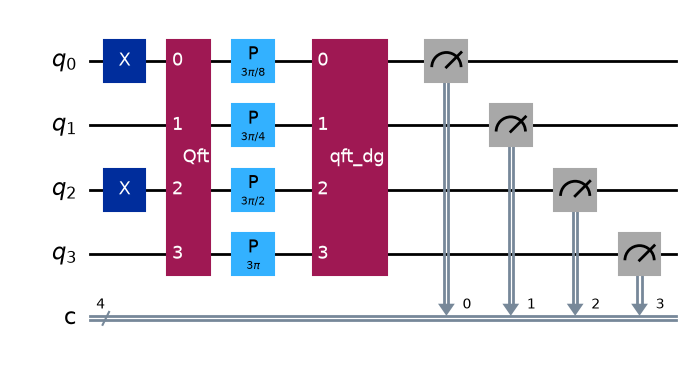

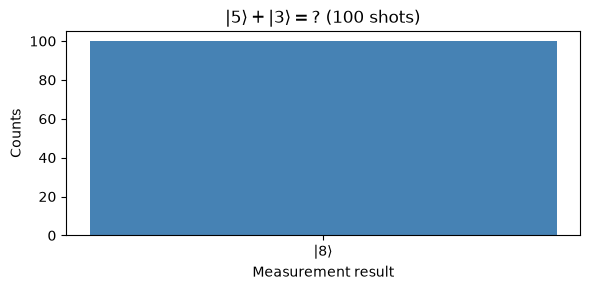

In [18]:
# --- Test circuit: add a=3 to b=5 ---

# Test parameters (separate from the main Shor circuit)
demo_circuit_bits = 4
demo_circuit_a = 3

# Compute θ_k with the get_angles function defined above
demo_circuit_angles = get_angles(demo_circuit_a, demo_circuit_bits)

# Create a 4-bit test circuit with Qiskit's QuantumCircuit
qc_demo = QuantumCircuit(demo_circuit_bits, demo_circuit_bits)

# Prepare |b=5⟩ = |0101⟩
# Apply an X gate to each bit that is 1 in the binary representation of 5
for i in range(demo_circuit_bits):
    if (5 >> i) & 1:      # shift 5 right by i bits and test whether the least significant bit is 1
        qc_demo.x(i)

# Add the QFT → phi_add(3) → IQFT sequence to the circuit
qc_demo.append(QFTGate(demo_circuit_bits), range(demo_circuit_bits))  # QFTGate (default: with swaps)
phi_add(qc_demo, demo_circuit_angles, list(range(demo_circuit_bits)))              # our own function: rotate the phases by θ_k
qc_demo.append(QFTGate(demo_circuit_bits).inverse(), range(demo_circuit_bits))  # IQFT

# .measure(qubits, clbits): measure qubits 0,1,2,3 and store them in classical bits 0,1,2,3, respectively
# range(4) = [0,1,2,3], so each qubit corresponds one-to-one to a classical bit
qc_demo.measure(range(demo_circuit_bits), range(demo_circuit_bits))

# Display the circuit diagram
print("Circuit diagram (example with b=5, a=3):")
display(qc_demo.draw('mpl'))

# --- Now run: execute the circuit we built on the simulator ---

# AerSimulator: the quantum-circuit simulator provided by Qiskit (a stand-in for real hardware)
sim_demo = AerSimulator(seed_simulator=SEED)

# sim_demo.run: run the circuit, measure demo_shots times, and look at the distribution of results
demo_shots = 100
qc_demo_t = transpile(qc_demo, sim_demo, optimization_level=0)
result_demo = sim_demo.run(qc_demo_t, shots=demo_shots, seed_simulator=SEED).result()

# The measurement results come back as a dict like {'1000': 100} (bit string: counts)
counts_demo = result_demo.get_counts()

# Plot the distribution
labels = [rf"$|{int(bs, 2)}\rangle$" for bs in counts_demo.keys()]
values = list(counts_demo.values())
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(labels, values, color='steelblue')
ax.set_xlabel('Measurement result')
ax.set_ylabel('Counts')
ax.set_title(rf'$|5\rangle + |3\rangle = ?$ ({demo_shots} shots)')
plt.tight_layout()
plt.show()

In the $b=5$ example above, all 100 measurements returned $|8\rangle$. At least in this example, the addition works correctly.\
In theory, the QFT → `phi_add` → IQFT operation maps the input $|b\rangle$ to $|b+a\rangle$ without creating a superposition, so ideally every measurement gives the same result no matter how many times we measure.

With this in mind, below we measure once for each of the 16 cases $b = 0, 1, \ldots, 15$ and confirm that the addition is performed correctly in every case.

In [19]:
# --- Verify all patterns ---
# Wrap the steps above in a function and loop over all patterns b = 0 to 15

def run_draper_add(b, a, n_bits, sim):
    """Compute |b⟩ + a with the Draper adder and return the measured result (an integer)"""
    angles = get_angles(a, n_bits)
    qc = QuantumCircuit(n_bits, n_bits)
    for i in range(n_bits):
        if (b >> i) & 1:
            qc.x(i)
    qc.append(QFTGate(n_bits), range(n_bits))
    phi_add(qc, angles, list(range(n_bits)))
    qc.append(QFTGate(n_bits).inverse(), range(n_bits))
    qc.measure(range(n_bits), range(n_bits))
    qc_t = transpile(qc, sim, optimization_level=0)
    result = sim.run(qc_t, shots=1, seed_simulator=SEED).result()
    return int(list(result.get_counts().keys())[0], 2)


verify_bits = 4
verify_a = 3
sim_verify = AerSimulator(seed_simulator=SEED)

print(f"=== Verifying all patterns: {verify_bits} bits, a={verify_a} ===")
print()

errors = 0
for b in range(2**verify_bits):       # b = 0, 1, 2, ..., 15
    expected = (b + verify_a) % (2**verify_bits)  # compute the expected value with ordinary addition (4 bits, so 16 and above overflow back to 0)
    measured = run_draper_add(b, verify_a, verify_bits, sim_verify)  # compute with the quantum circuit
    # Compare the quantum-circuit result with the expected value
    ok = "OK" if measured == expected else "NG"
    if measured != expected:
        errors += 1
    print(f"  |{b}⟩ + {verify_a} = |{measured}⟩  (expected: |{expected}⟩)  {ok}")

print()
if errors == 0:
    print(f"All {2**verify_bits} patterns succeeded!")
    print("→ The phase rotations of phi_add add correctly for every input.")

=== Verifying all patterns: 4 bits, a=3 ===

  |0⟩ + 3 = |3⟩  (expected: |3⟩)  OK
  |1⟩ + 3 = |4⟩  (expected: |4⟩)  OK
  |2⟩ + 3 = |5⟩  (expected: |5⟩)  OK


  |3⟩ + 3 = |6⟩  (expected: |6⟩)  OK
  |4⟩ + 3 = |7⟩  (expected: |7⟩)  OK
  |5⟩ + 3 = |8⟩  (expected: |8⟩)  OK
  |6⟩ + 3 = |9⟩  (expected: |9⟩)  OK


  |7⟩ + 3 = |10⟩  (expected: |10⟩)  OK
  |8⟩ + 3 = |11⟩  (expected: |11⟩)  OK
  |9⟩ + 3 = |12⟩  (expected: |12⟩)  OK
  |10⟩ + 3 = |13⟩  (expected: |13⟩)  OK


  |11⟩ + 3 = |14⟩  (expected: |14⟩)  OK
  |12⟩ + 3 = |15⟩  (expected: |15⟩)  OK
  |13⟩ + 3 = |0⟩  (expected: |0⟩)  OK
  |14⟩ + 3 = |1⟩  (expected: |1⟩)  OK


  |15⟩ + 3 = |2⟩  (expected: |2⟩)  OK

All 16 patterns succeeded!
→ The phase rotations of phi_add add correctly for every input.


##### **Building the Controlled Adders**

The "modular addition (Level 1)" stage of the Shor circuit requires a "controlled adder" that switches between "add / do not add" on the target register depending on the state of another qubit (the control qubit).

Whereas `phi_add` "always adds the constant $a$ to the target register," the controlled version "adds the constant $a$ to the target register only when the control qubit (a qubit on another register) is $|1\rangle$, and does nothing when it is $|0\rangle$." Even when the control qubit is in a superposition, the different operations are applied simultaneously to the $|0\rangle$ component and the $|1\rangle$ component.



> **What to do**\
● Define a function `c_phi_add` that adds only when the control qubit is $|1\rangle$, using Qiskit's `cp(θ, ctrl, target)`.\
● Likewise, define a function `cc_phi_add` that adds only when both of the two control qubits are $|1\rangle$, using `PhaseGate(θ).control(2)`.

In [20]:
# --- Single-control version ---
# PhaseGate(θ).control(1) attaches one control qubit to the phase gate
def c_phi_add(qc, angles, ctrl_qubit, target_qubits):
    """Addition with one control qubit: rotate the phases only when ctrl is |1⟩"""
    for i in range(len(target_qubits)):
        if abs(angles[i]) > 1e-15:
            gate = PhaseGate(angles[i]).control(1)
            qc.append(gate, [ctrl_qubit, target_qubits[i]])


# --- Two-control version ---
# PhaseGate(θ).control(2) attaches two control qubits to the phase gate
def cc_phi_add(qc, angles, ctrl1, ctrl2, target_qubits):
    """Addition with two control qubits: rotate the phases only when both ctrl1 and ctrl2 are |1⟩"""
    for i in range(len(target_qubits)):
        if abs(angles[i]) > 1e-15:
            gate = PhaseGate(angles[i]).control(2)
            qc.append(gate, [ctrl1, ctrl2, target_qubits[i]])

##### **Verifying the Controlled Adder (`c_phi_add`)**

We confirm that the addition of the constant $a$ to $|b\rangle$ ($|b\rangle \to |b+a\rangle$) is performed only when the control qubit is $|1\rangle$, and that nothing happens when it is $|0\rangle$.

> ※ This is a test circuit, separate from the main Shor circuit.

In [21]:
# --- Verifying c_phi_add ---
test_bits = 4
test_a = 3
test_b = 5
test_angles = get_angles(test_a, test_bits)
sim_ctrl = AerSimulator(seed_simulator=SEED)

# === Case 1: control qubit = |0⟩ (no addition should occur) ===
qc_ctrl0 = QuantumCircuit(1 + test_bits, test_bits)
ctrl_idx = 0
tgt_indices = list(range(1, 1 + test_bits))
# The control qubit stays |0⟩ (the default)
# Set the target to |b=5⟩ = |0101⟩
for i in range(test_bits):
    if (test_b >> i) & 1:
        qc_ctrl0.x(tgt_indices[i])
qc_ctrl0.append(QFTGate(test_bits), tgt_indices)
c_phi_add(qc_ctrl0, test_angles, ctrl_idx, tgt_indices)
qc_ctrl0.append(QFTGate(test_bits).inverse(), tgt_indices)
qc_ctrl0.measure(tgt_indices, range(test_bits))

result0 = sim_ctrl.run(transpile(qc_ctrl0, sim_ctrl, optimization_level=0), shots=1, seed_simulator=SEED).result()
measured0 = int(list(result0.get_counts().keys())[0], 2)
print(f"ctrl=|0⟩: |{test_b}⟩ → |{measured0}⟩  → {'unchanged' if measured0 == test_b else 'NG'}")

# === Case 2: control qubit = |1⟩ (addition should occur) ===
qc_ctrl1 = QuantumCircuit(1 + test_bits, test_bits)
ctrl_idx = 0
tgt_indices = list(range(1, 1 + test_bits))
qc_ctrl1.x(ctrl_idx)  # set the control qubit |0⟩ → |1⟩
for i in range(test_bits):
    if (test_b >> i) & 1:
        qc_ctrl1.x(tgt_indices[i])
qc_ctrl1.append(QFTGate(test_bits), tgt_indices)
c_phi_add(qc_ctrl1, test_angles, ctrl_idx, tgt_indices)
qc_ctrl1.append(QFTGate(test_bits).inverse(), tgt_indices)
qc_ctrl1.measure(tgt_indices, range(test_bits))

result1 = sim_ctrl.run(transpile(qc_ctrl1, sim_ctrl, optimization_level=0), shots=1, seed_simulator=SEED).result()
measured1 = int(list(result1.get_counts().keys())[0], 2)
print(f"ctrl=|1⟩: |{test_b}⟩ → |{measured1}⟩  → {test_b}+{test_a}={test_b+test_a}")

print()
print("→ Addition happens only when the control qubit is |1⟩; nothing happens when it is |0⟩.")

ctrl=|0⟩: |5⟩ → |5⟩  → unchanged
ctrl=|1⟩: |5⟩ → |8⟩  → 5+3=8

→ Addition happens only when the control qubit is |1⟩; nothing happens when it is |0⟩.


Now consider, on the other hand, the case where the control qubit is in a superposition.\
If we apply a Hadamard gate to the control qubit to put it in $(|0\rangle + |1\rangle)/\sqrt{2}$, the state before applying the controlled addition is as follows.

$$\frac{1}{\sqrt{2}}\left(|0\rangle_{\text{ctrl}} + |1\rangle_{\text{ctrl}}\right) \otimes |5\rangle_{\text{target}}$$

The control qubit and the target are independent (a product state). Applying `c_phi_add` to this state, we can compute the result as follows.

$$\frac{1}{\sqrt{2}}\left(|0\rangle_{\text{ctrl}} \otimes |5\rangle + |1\rangle_{\text{ctrl}} \otimes |8\rangle\right)$$

The addition does not act on the $|0\rangle$ component, which stays $|5\rangle$, while it does act on the $|1\rangle$ component, which becomes $|8\rangle$.\
In the state above, measuring the target should yield $|5\rangle$ and $|8\rangle$ each with probability $\frac{1}{2}$. In the next cell we actually measure 500 times and check whether the distribution really is roughly half and half.

> ※ The state above, $(|0\rangle \otimes |5\rangle + |1\rangle \otimes |8\rangle)/\sqrt{2}$, is a state in which the control qubit and the target register are **entangled**. That is, the overall state cannot be decomposed into the form $|\psi\rangle_{\text{ctrl}} \otimes |\phi\rangle_{\text{target}}$. You do not need to understand the details of entanglement to work through this hands-on; interested readers should see (→ Book, "The Steps of Shor's Algorithm", Box).

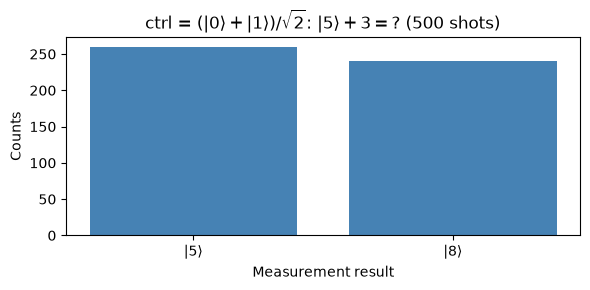

→ |5⟩ (not added): 260 times (52%), |8⟩ (added): 240 times (48%) → roughly half and half


In [22]:
# --- Apply c_phi_add with the control qubit in a superposition ---
# The only difference from the previous cell is the control-qubit initialization:
#   previous cell: qc.x(ctrl_idx)  → set to |1⟩
#   this cell: qc.h(ctrl_idx)  → set to (|0⟩+|1⟩)/√2

qc_H = QuantumCircuit(1 + test_bits, test_bits)
ctrl_idx = 0
tgt_indices = list(range(1, 1 + test_bits))

qc_H.h(ctrl_idx)  # ← the only change: |0⟩ → (|0⟩+|1⟩)/√2

# The rest is the same as the previous cell
for i in range(test_bits):
    if (test_b >> i) & 1:
        qc_H.x(tgt_indices[i])
qc_H.append(QFTGate(test_bits), tgt_indices)
c_phi_add(qc_H, test_angles, ctrl_idx, tgt_indices)
qc_H.append(QFTGate(test_bits).inverse(), tgt_indices)
qc_H.measure(tgt_indices, range(test_bits))

# Because of the superposition, measure many times and look at the distribution
H_shots = 500
result_H = sim_ctrl.run(transpile(qc_H, sim_ctrl, optimization_level=0), shots=H_shots, seed_simulator=SEED).result()
counts_H = result_H.get_counts()

# Plot the distribution
labels = [rf"$|{int(bs, 2)}\rangle$" for bs in sorted(counts_H.keys())]
values = [counts_H[bs] for bs in sorted(counts_H.keys())]
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(labels, values, color='steelblue')
ax.set_xlabel('Measurement result')
ax.set_ylabel('Counts')
ax.set_title(rf'ctrl = $(|0\rangle+|1\rangle)/\sqrt{{2}}$: $|{test_b}\rangle + {test_a} = ?$ ({H_shots} shots)')
plt.tight_layout()
plt.show()

# Show the actual counts
b_str = format(test_b, f'0{test_bits}b')
b_plus_a_str = format(test_b + test_a, f'0{test_bits}b')
count_b = counts_H.get(b_str, 0)
count_b_plus_a = counts_H.get(b_plus_a_str, 0)
print(f"→ |{test_b}⟩ (not added): {count_b} times ({count_b/H_shots*100:.0f}%), "
      f"|{test_b+test_a}⟩ (added): {count_b_plus_a} times ({count_b_plus_a/H_shots*100:.0f}%) → roughly half and half")

##### **Verifying the Doubly Controlled Adder (`cc_phi_add`)**

`cc_phi_add` adds only when **both** of the two control qubits are $|1\rangle$. We check by trying all four patterns $(|0\rangle,|0\rangle), (|1\rangle,|0\rangle), (|0\rangle,|1\rangle), (|1\rangle,|1\rangle)$.

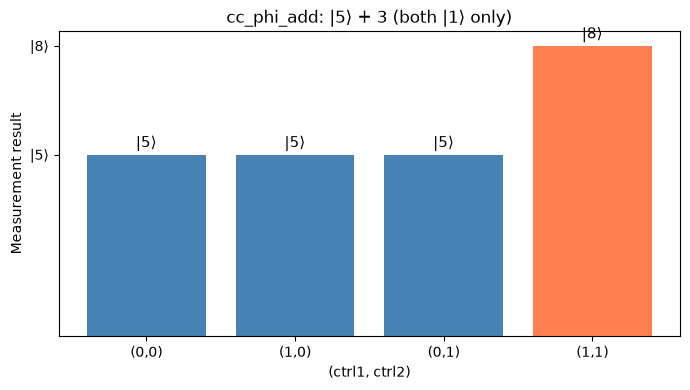

→ Only for (1,1) does |5⟩ change to |8⟩ (an AND condition).
  In all other cases it stays |5⟩.


In [23]:
# --- Verifying cc_phi_add: the 4 patterns ---
# Same structure as c_phi_add, but with two control qubits. Addition happens only when both are |1⟩.

patterns = [(0,0), (1,0), (0,1), (1,1)]
results_cc = {}

for c1, c2 in patterns:
    qc = QuantumCircuit(2 + test_bits, test_bits)
    ctrl1_idx, ctrl2_idx = 0, 1
    tgt_indices = list(range(2, 2 + test_bits))

    if c1 == 1:
        qc.x(ctrl1_idx)
    if c2 == 1:
        qc.x(ctrl2_idx)

    for i in range(test_bits):
        if (test_b >> i) & 1:
            qc.x(tgt_indices[i])

    qc.append(QFTGate(test_bits), tgt_indices)
    cc_phi_add(qc, test_angles, ctrl1_idx, ctrl2_idx, tgt_indices)
    qc.append(QFTGate(test_bits).inverse(), tgt_indices)
    qc.measure(tgt_indices, range(test_bits))

    result = sim_ctrl.run(transpile(qc, sim_ctrl, optimization_level=0), shots=1, seed_simulator=SEED).result()
    measured = int(list(result.get_counts().keys())[0], 2)
    results_cc[(c1,c2)] = measured

# Plot the results
labels = [f"({c1},{c2})" for c1, c2 in patterns]
values = [results_cc[p] for p in patterns]
colors = ['steelblue' if v == test_b else 'coral' for v in values]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, values, color=colors)
ax.set_xlabel('(ctrl1, ctrl2)')
ax.set_ylabel('Measurement result')
ax.set_title(rf'cc_phi_add: $|{test_b}\rangle$ + {test_a} (both $|1\rangle$ only)')
ax.set_yticks(sorted(set(values)))
ax.set_yticklabels([rf"$|{v}\rangle$" for v in sorted(set(values))])

# Show the value on each bar
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            rf"$|{v}\rangle$", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

print(f"→ Only for (1,1) does |{test_b}⟩ change to |{test_b+test_a}⟩ (an AND condition).")
print(f"  In all other cases it stays |{test_b}⟩.")

#### **Where We Are and What Comes Next**



In Level 0 we built addition in Fourier space (`phi_add`) and its controlled versions (`c_phi_add`, `cc_phi_add`). However, Shor's algorithm needs not plain addition but "addition with $\bmod n$". In the next Level 1, we use the Level 0 adders as building blocks to realize $(b + a) \bmod n$.



#### **Level 1: Modular Addition in Fourier Space**



Level 0 gave us "addition in Fourier space". Next, we add **the $\bmod n$ handling** to this and compute $(b + a) \bmod n$.




##### **The Idea Behind Modular Addition**



To realize $(b + a) \bmod n$, we follow the steps below.

1. **Add $a$**\
Compute $(b + a)$ with `cc_phi_add` from Level 0
2. **Subtract $n$**\
Add $-n$ with `phi_add` to obtain $(b + a - n)$
3. **Check whether the result is negative**\
If $(b + a - n) < 0$, we subtracted $n$ one time too many, so add $n$ back

For this "is it negative?" check we use an auxiliary qubit (called an ancilla). This requires temporarily leaving Fourier space to inspect the most significant bit (the sign bit), and then returning to Fourier space again.

> **What to do**\
● Create `cc_phi_add_mod`, a modular-addition function that implements Steps 1–3 above in Qiskit.\
● Define its inverse operation, `cc_phi_add_mod_inv`. Quantum gates are unitary, so the inverse transformation ($U^\dagger$) always exists; each gate used in `cc_phi_add_mod` can therefore be inverted, and the inverse operation is built simply by applying the inverted gates in reverse order. It will be needed inside Level 2


In [24]:
# --- Level 1: modular addition ---
# Combine the Level 0 functions to realize (b+a) mod n.
# Steps 1–3 explained above translate directly into the code below.

def cc_phi_add_mod(qc, a_val, n_val, ctrl1, ctrl2, target_qubits, ancilla):
    """Doubly controlled modular addition: computes (b + a) mod n in Fourier space

    Args:
        qc: quantum circuit
        a_val: constant to add
        n_val: modulus n
        ctrl1, ctrl2: control qubits (addition happens when both are |1⟩)
        target_qubits: register to add into (assumed to be in Fourier space)
        ancilla: ancilla qubit (used for the sign check)
    """
    n_bits = len(target_qubits)
    angles_a = get_angles(a_val, n_bits)       # angles for +a
    angles_n = get_angles(n_val, n_bits)       # angles for +n
    angles_neg_a = get_angles((2**n_bits) - a_val, n_bits)  # angles for -a
    angles_neg_n = get_angles((2**n_bits) - n_val, n_bits)  # angles for -n

    # --- Step 1: add a (only when ctrl1 and ctrl2 are both |1⟩) ---
    cc_phi_add(qc, angles_a, ctrl1, ctrl2, target_qubits)

    # --- Step 2: subtract n (unconditionally) ---
    phi_add(qc, angles_neg_n, target_qubits)

    # --- Step 3: check whether the result is negative; if so, add n back ---
    qc.append(QFTGate(n_bits).inverse(), target_qubits)  # Fourier → computational basis
    qc.cx(target_qubits[n_bits - 1], ancilla)  # copy the most significant bit (the sign) to the ancilla (in two's complement, MSB 1 = negative)
    qc.append(QFTGate(n_bits), target_qubits)            # computational basis → Fourier
    # If the ancilla is 1 (= the result was negative), add n back
    # Here we use ancilla as the control qubit of c_phi_add
    c_phi_add(qc, angles_n, ancilla, target_qubits)

    # --- Restore the ancilla to |0⟩ (uncomputation) ---
    # If the ancilla became |1⟩ in Step 3, leaving it as is would leave it entangled with the other registers and corrupt the results of the computation from here on.
    # We therefore need to return it to |0⟩, but no such operation exists among quantum gates.
    # Instead, we use a technique that returns it to |0⟩ using only unitary operations.
    # This is called uncomputation, and it is a general principle for handling ancilla qubits in quantum computation.
    #
    # (1) Temporarily restore the target to b, its state before a was added in Step 1
    cc_phi_add(qc, angles_neg_a, ctrl1, ctrl2, target_qubits)  # restore (b+a) mod n → b
    #
    # (2) Use the sign bit of the restored state b to return the ancilla to |0⟩
    #    Since b >= 0, the sign bit is 0. Flip it with an X gate, apply cx to act on the ancilla, then flip it back with X
    qc.append(QFTGate(n_bits).inverse(), target_qubits)  # Fourier → computational basis
    qc.x(target_qubits[n_bits - 1])            # flip the sign bit (0→1)
    qc.cx(target_qubits[n_bits - 1], ancilla)  # if the ancilla is |1⟩, it returns to |0⟩
    qc.x(target_qubits[n_bits - 1])            # restore the sign bit (1→0)
    qc.append(QFTGate(n_bits), target_qubits)           # computational basis → Fourier
    #
    # (3) Advance the target back to the final result (b+a) mod n
    cc_phi_add(qc, angles_a, ctrl1, ctrl2, target_qubits)     # take b → (b+a) mod n again


def cc_phi_add_mod_inv(qc, a_val, n_val, ctrl1, ctrl2, target_qubits, ancilla):
    """Inverse of cc_phi_add_mod: applies all of the above operations in reverse order"""
    n_bits = len(target_qubits)
    angles_a = get_angles(a_val, n_bits)
    angles_n = get_angles(n_val, n_bits)
    angles_neg_a = get_angles((2**n_bits) - a_val, n_bits)
    angles_neg_n = get_angles((2**n_bits) - n_val, n_bits)

    cc_phi_add(qc, angles_neg_a, ctrl1, ctrl2, target_qubits)
    qc.append(QFTGate(n_bits).inverse(), target_qubits)
    qc.x(target_qubits[n_bits - 1])
    qc.cx(target_qubits[n_bits - 1], ancilla)
    qc.x(target_qubits[n_bits - 1])
    qc.append(QFTGate(n_bits), target_qubits)
    cc_phi_add(qc, angles_a, ctrl1, ctrl2, target_qubits)
    c_phi_add(qc, angles_neg_n, ancilla, target_qubits)
    qc.append(QFTGate(n_bits).inverse(), target_qubits)
    qc.cx(target_qubits[n_bits - 1], ancilla)
    qc.append(QFTGate(n_bits), target_qubits)
    phi_add(qc, angles_n, target_qubits)
    cc_phi_add(qc, angles_neg_a, ctrl1, ctrl2, target_qubits)


print("Level 1 functions defined")
print("  cc_phi_add_mod:     computes (b + a) mod n")
print("  cc_phi_add_mod_inv: the inverse of the above")

Level 1 functions defined
  cc_phi_add_mod:     computes (b + a) mod n
  cc_phi_add_mod_inv: the inverse of the above


##### **Verifying Modular Addition**



We check that `cc_phi_add_mod` correctly computes $(b + a) \bmod n$.

> **What to do**\
Use cc_phi_add_mod to compute $(b + a) \bmod n$

> ※ This is a test circuit, separate from the main Shor circuit.

In [25]:
# --- Verifying Level 1: check with one concrete example ---
# Feel free to change the variables below and try other patterns
test_n = 7    # modulus n
test_a = 5    # constant a to add
test_b = 3    # input value b
expected = (test_b + test_a) % test_n  # expected value from classical computation

N_mod = ceil(log2(test_n))
n_acc = N_mod + 1

# Test circuit: 2 control qubits + accumulator (n_acc) + ancilla (1)
qc_mod = QuantumCircuit(2 + n_acc + 1, n_acc)
ctrl1_idx, ctrl2_idx = 0, 1
acc_indices = list(range(2, 2 + n_acc))
anc_idx = 2 + n_acc

# Set both control qubits to |1⟩ (the condition for cc_phi_add_mod to act)
qc_mod.x(ctrl1_idx)
qc_mod.x(ctrl2_idx)

# Set the target to |b⟩
for i in range(n_acc):
    if (test_b >> i) & 1:
        qc_mod.x(acc_indices[i])

# QFT → cc_phi_add_mod → IQFT → measurement
qc_mod.append(QFTGate(n_acc), acc_indices)
cc_phi_add_mod(qc_mod, test_a, test_n, ctrl1_idx, ctrl2_idx, acc_indices, anc_idx)
qc_mod.append(QFTGate(n_acc).inverse(), acc_indices)
qc_mod.measure(acc_indices, range(n_acc))

sim_mod = AerSimulator(seed_simulator=SEED)
result_mod = sim_mod.run(transpile(qc_mod, sim_mod, optimization_level=0), shots=1, seed_simulator=SEED).result()
measured = int(list(result_mod.get_counts().keys())[0], 2)

print(f"({test_b} + {test_a}) mod {test_n} = {measured}  (expected: {expected})  {'OK!' if measured == expected else 'NG'}")

(3 + 5) mod 7 = 1  (expected: 1)  OK!


#### **Where We Are and What Comes Next**



As building blocks of the Shor circuit, we have worked our way up from Level 0 (addition) to Level 1 (modular addition). Now that Level 1 gives us the modular addition $(b + a) \bmod n$, the next step is to repeat it to realize modular multiplication.

As stated in "Preparing for Step 3", the modular multiplication $c \times x \bmod n$ can be realized by repeated modular addition.

$$c \times x \bmod n = \sum_k (c \cdot 2^k) \cdot x_k \bmod n$$

In other words, using each bit $x_k$ of $x$ as a control qubit, we repeat the modular addition of $c \cdot 2^k$. This is Level 2's `c_mult_mod`; in Step 3 of the Shor circuit, we plug this function into the circuit built up through Step 2 to realize the controlled modular exponentiation $U_{a,n}^{2^k}$.





#### **Level 2: Controlled Modular Multiplication**



##### **Defining Controlled Modular Multiplication**



**⭐ Implementation Note**

In Levels 0/1, the "control qubits" and the "register being added into" were separate things. In the Level 2 modular multiplication, however, each bit of $|x\rangle$ is also used as a control qubit for the modular additions, so $|x\rangle$ doubles as both the control qubits and the destination for the computed result. If the value of $|x\rangle$ changed while its bits were being used one after another as control qubits, the control for the subsequent bits would be corrupted — so we cannot write the addition results directly into $|x\rangle$.

The Beauregard construction handles this problem with a "separate register $|acc\rangle$", using the following procedure.

1. Accumulate the results of the modular additions into $|acc\rangle$\
This gives $|acc\rangle = |c \cdot x \bmod n\rangle$. Here, $|x\rangle$ is left unchanged
2. Swap the contents of $|x\rangle$ and $|acc\rangle$ (cswap)
3. Restore the original value left in $|acc\rangle$ to $|0\rangle$ (uncomputation)

As a result, $|x\rangle$ ends up holding the computed result $|c \cdot x \bmod n\rangle$, and $|acc\rangle$ returns to $|0\rangle$.



In [26]:
# --- Level 2: controlled modular multiplication ---
def c_mult_mod(qc, a_val, a_inv_val, n_val, ctrl_qubit, x_qubits, acc_qubits, ancilla):
    """Controlled modular multiplication: |x⟩ → |a_val*x mod n⟩ when ctrl=|1⟩
     (a_val corresponds to the constant c in the explanation in the previous cell. In Step 3 of Shor it is called with c = a^{2^k} mod n)

    Args:
        a_val: constant c to multiply by
        a_inv_val: inverse of c, i.e. c⁻¹ mod n (used in the uncomputation in the second half)
        n_val: modulus n
        ctrl_qubit: control qubit
        x_qubits: register holding the input |x⟩ (in the end this holds c·x mod n)
        acc_qubits: addition register (used for intermediate work, restored to |0⟩ at the end)
        ancilla: ancilla qubit (used for the sign check in the modular additions)
    """
    n_x = len(x_qubits)
    n_acc = len(acc_qubits)

    # --- Block 1: compute c·x mod n into acc ---
    # Repeat the modular addition of a_val·2^i, using each bit x_i of x as a control qubit
    qc.append(QFTGate(n_acc), acc_qubits)  # transform acc into Fourier space
    for i in range(n_x):
        a_shifted = (pow(2, i, n_val) * a_val) % n_val  # a_val·2^i mod n
        cc_phi_add_mod(qc, a_shifted, n_val, ctrl_qubit, x_qubits[i], acc_qubits, ancilla)
    qc.append(QFTGate(n_acc).inverse(), acc_qubits)  # back from Fourier to the computational basis

    # After Block 1: |x⟩ = the original x unchanged, |acc⟩ = a_val·x mod n (the accumulated result of the modular additions)

    # --- Block 2: swap x and acc ---
    # Before the swap: x = the original x, acc = c·x mod n
    # After the swap: x = c·x mod n (the result we want), acc = the original x
    for i in range(n_x):
        qc.cswap(ctrl_qubit, x_qubits[i], acc_qubits[i])

    # After Block 2: |x⟩ = a_val·x mod n (the result we want), |acc⟩ = the original x (which must be restored to |0⟩)

    # --- Block 3: restore acc to |0⟩ (uncomputation) ---
    # acc still holds the original x. Using a_inv_val, the inverse of a_val,
    # we restore acc to |0⟩ with the inverse operation (cc_phi_add_mod_inv)
    qc.append(QFTGate(n_acc), acc_qubits)
    for i in range(n_x - 1, -1, -1):
        a_inv_shifted = (pow(2, i, n_val) * a_inv_val) % n_val  # a_inv_val·2^i mod n
        cc_phi_add_mod_inv(qc, a_inv_shifted, n_val, ctrl_qubit, x_qubits[i], acc_qubits, ancilla)
    qc.append(QFTGate(n_acc).inverse(), acc_qubits)


print("Level 2 function defined: c_mult_mod")

Level 2 function defined: c_mult_mod


##### **Verifying Controlled Modular Multiplication**

We check with a concrete example that `c_mult_mod` correctly realizes $|x\rangle \to |c \cdot x \bmod n\rangle$. You can try other values by changing the variables below.

> ※ This is a test circuit, separate from the main Shor circuit.

In [27]:
# --- Verifying Level 2: |x⟩ → |c·x mod n⟩ ---
test_c, test_n, test_x = 7, 15, 3  # 7×3=21, 21 mod 15=6 (an example where the mod actually kicks in)
test_c_inv = pow(test_c, -1, test_n)  # inverse of c (needed for the uncomputation inside c_mult_mod)
N_cm = ceil(log2(test_n))   # number of bits to represent n in binary (ceil = round up)
n_acc_cm = N_cm + 1            # number of bits in the acc register

qc_cm = QuantumCircuit(1 + N_cm + n_acc_cm + 1, N_cm)
qc_cm.x(0)                                          # control qubit = |1⟩
for i in range(N_cm):
    if (test_x >> i) & 1: qc_cm.x(1 + i)            # set |x=3⟩
c_mult_mod(qc_cm, test_c, test_c_inv, test_n, 0,
           list(range(1, 1+N_cm)), list(range(1+N_cm, 1+N_cm+n_acc_cm)), 1+N_cm+n_acc_cm)
qc_cm.measure(list(range(1, 1+N_cm)), list(range(N_cm)))

measured = int(list(AerSimulator(seed_simulator=SEED).run(transpile(qc_cm, AerSimulator(), optimization_level=0), shots=1, seed_simulator=SEED).result().get_counts().keys())[0], 2)
expected = (test_c * test_x) % test_n
print(f"|{test_x}⟩ → |{measured}⟩  (expected: |{expected}⟩ = |{test_c}×{test_x} mod {test_n}⟩)  {'OK!' if measured == expected else 'NG'}")

|3⟩ → |6⟩  (expected: |6⟩ = |7×3 mod 15⟩)  OK!


**Step 3: Controlled Modular Exponentiation (→ Book, "The Steps of Shor's Algorithm", Step 3)**





In the cell just above, we implemented `c_mult_mod`, which realizes the modular multiplication $|x\rangle \to |c \cdot x \bmod n\rangle$, and finished verifying it.

In this hands-on, we implement Shor's algorithm in the following six steps. (→ Book, "The Steps of Shor's Algorithm". In this hands-on, see the table at the beginning of the "Running the Circuit" section)

1. ~~Preparing the initial state~~ ✓
2. ~~Hadamard gates~~ ✓
3. **Controlled modular exponentiation** ← we are here
4. Inverse QFT
5. Measurement
6. Continued-fraction expansion → factoring


In Step 3, we want to transform the target register of the Shor circuit built up through Step 2 from $|1\rangle$ to $|a^z \bmod n\rangle$.

$$|\psi_2\rangle = \frac{1}{\sqrt{2^M}} \sum_{z=0}^{2^M-1} |z\rangle_{\mathcal{M}} \otimes |1\rangle_{\mathcal{N}} \quad \xrightarrow{\text{Step 3}} \quad |\psi_3\rangle = \frac{1}{\sqrt{2^M}} \sum_{z=0}^{2^M-1} |z\rangle_{\mathcal{M}} \otimes |a^z \bmod n\rangle_{\mathcal{N}}$$

`c_mult_mod` is a function that takes a constant $c$ precomputed classically. Here, however, $z$ is the quantum state of the control register, which is in the superposition $|0\rangle + |1\rangle + \cdots + |2^M - 1\rangle$. The value of $z$ is not determined until measurement, so we cannot precompute $c = a^z$ and have it ready in advance.

So let us use the binary expansion of $z$ to decompose $a^z$.

$$z = z_0 \cdot 2^0 + z_1 \cdot 2^1 + \cdots + z_k \cdot 2^k + \cdots + z_{M-1} \cdot 2^{M-1}$$



$$a^z = (a^{2^0})^{z_0} \cdot (a^{2^1})^{z_1} \cdots (a^{2^k})^{z_k} \cdots (a^{2^{M-1}})^{z_{M-1}}$$

Each $z_k$ corresponds to the state ($|0\rangle$ or $|1\rangle$) of the $k$-th qubit of the control register. In other words, if we arrange to multiply by $a^{2^k}$ only when $z_k = |1\rangle$, the overall effect is exactly the desired transformation to $|a^z \bmod n\rangle$.

As for the implementation, the control register's $|z\rangle$ is really $|z_0\rangle \otimes |z_1\rangle \otimes \cdots \otimes |z_{M-1}\rangle$, and each $|z_k\rangle$ can be accessed individually as `ctrl[k]` in Qiskit. Therefore, if we call `c_mult_mod` with `ctrl[k]` as the control qubit, the multiplication by $a^{2^k}$ happens only when `ctrl[k]` $= |1\rangle$. Since $c = a^{2^k} \bmod n$ is a constant that can be obtained in advance by classical computation for each $k$, all we need to do is add M instances of `c_mult_mod` to the circuit, covering every $k = 0, 1, \ldots, M-1$.

> **What to do**:
> - Precompute $a^{2^k} \bmod n$ classically for $k=0,\ldots,M-1$
> - For each $k$, add `c_mult_mod(c=a^{2^k})` to the circuit with `ctrl[k]` as the control qubit

> Running this step takes a few seconds.

In [28]:
# --- Step 3: Controlled modular exponentiation ---
# Start from the state at the end of Step 2 (safe to re-run)
qc = qc_step2.copy()

# --- Classical precomputation: compute c = a^{2^k} mod n for each k ---
for k in range(M):
    c_k = pow(a, 1 << k, n_number)  # 1 << k is the same as 2^k (bit shift)
    print(f"  k={k}: c = {a}^(2^{k}) mod {n_number} = {c_k}")
print()

# --- Add the M c_mult_mod blocks to the circuit ---
# For each k, use ctrl[k] (the k-th qubit of the control register = z_k) as the control qubit
# and add c_mult_mod(c = a^{2^k}) to the circuit
print("Applying the controlled modular exponentiation...")
t_start = time.time()
for k in range(M):
    c_k = pow(a, 1 << k, n_number)        # c = a^{2^k} mod n
    c_k_inv = pow(c_k, -1, n_number)        # inverse of c_k (used for the uncomputation inside c_mult_mod)
    # Apply ×c_k to the target only when ctrl[k] is |1⟩
    c_mult_mod(qc, c_k, c_k_inv, n_number, ctrl[k], list(x), list(acc), anc[0])
qc.barrier(label='Step3: CU')
t_step3 = time.time() - t_start

print(f"Step 3 complete: {t_step3:.2f} s")
print(f"  Current circuit — gate count: {qc.size()},  depth: {qc.depth()}")
print()
print("Current circuit (up to Step 3):")
fig = qc.draw('mpl', fold=40)
fig.savefig('step3_circuit.png', dpi=150, bbox_inches='tight')
plt.close(fig)
print(f'Circuit diagram saved to step3_circuit.png (saved as a file instead of embedding it in the notebook)')

# Save the circuit as of the end of Step 3
qc_step3 = qc.copy()

  k=0: c = 7^(2^0) mod 15 = 7
  k=1: c = 7^(2^1) mod 15 = 4
  k=2: c = 7^(2^2) mod 15 = 1
  k=3: c = 7^(2^3) mod 15 = 1
  k=4: c = 7^(2^4) mod 15 = 1
  k=5: c = 7^(2^5) mod 15 = 1
  k=6: c = 7^(2^6) mod 15 = 1
  k=7: c = 7^(2^7) mod 15 = 1

Applying the controlled modular exponentiation...


Step 3 complete: 0.07 s
  Current circuit — gate count: 2185,  depth: 1665

Current circuit (up to Step 3):


Circuit diagram saved to step3_circuit.png (saved as a file instead of embedding it in the notebook)


Through Steps 1–3, the circuit has realized the following state.

$$|\psi_3\rangle = \frac{1}{\sqrt{2^M}} \sum_{z=0}^{2^M-1} |z\rangle \otimes |a^z \bmod n\rangle$$

For $n=15, a=7$, the target values corresponding to each $|z\rangle$ in the control register are as follows.

| $z$ | 0 | 1 | 2 | 3 | **4** | 5 | 6 | 7 | **8** | … |
|-----|---|---|---|---|-------|---|---|---|-------|---|
| $7^z \bmod 15$ | 1 | 7 | 4 | 13 | **1** | 7 | 4 | 13 | **1** | … |

Looking at the table above, the same pattern repeats every $4$ values of $z$. In other words, the information about the order $r=4$ is embedded in this periodic structure.

However, if we measure the control register as it is, we simply obtain $z = 0, 1, 2, \ldots, 255$ with equal probability, and the period $r$ cannot be read off.

In the next step, Step 4, we apply the inverse quantum Fourier transform (IQFT) to convert this periodic structure into a distribution with peaks at specific values of $z$.

### **Step 4: The Inverse Quantum Fourier Transform**



(→ Book, "The Steps of Shor's Algorithm", Step 4)

As we saw in the previous cell, measuring the state after Step 3 as it is simply yields every value of $z$ with equal probability, and the period $r$ cannot be read off.

The inverse quantum Fourier transform (IQFT) is the operation that converts the periodic structure of the control register into a distribution with peaks at specific values of $z$ (→ Book, "Quantum Phase Estimation"). Concretely, when we measure the control register after applying the IQFT, the outcomes concentrate in peaks at the $r$ positions $z = s \cdot 2^M / r$ ($s = 0, 1, \ldots, r-1$).

For $n=15, r=4, M=8$, this works out as follows.

| $s$ | Measured value $z = s \cdot 2^M / r$ | $z / 2^M$ |
|-----|-------------------------------|----------|
| 0 | $0$ | $0$ |
| 1 | $64$ | $0.25 = 1/4$ |
| 2 | $128$ | $0.50 = 2/4$ |
| 3 | $192$ | $0.75 = 3/4$ |

The order $r$ appears in the denominator of $z / 2^M = s/r$. From this we can recover $r$ (→ Step 6 uses the continued-fraction expansion).

In Qiskit, `QFTGate(...).inverse()` automatically generates the IQFT circuit.

> **What to do**\
● Apply the IQFT to the control register  
● In the next step, Step 5, measure the control register and confirm that peaks appear at $z = 0, 64, 128, 192$, as in the table above.

In [29]:
# --- Step 4: Inverse quantum Fourier transform ---
# Start from the state at the end of Step 3 (safe to re-run)
qc = qc_step3.copy()

# Generate the M-qubit inverse QFT circuit (the inverse of the QFT)
iqft = QFTGate(M).inverse()
iqft.name = 'IQFT'

# Apply the IQFT to the control register ctrl (periodic structure → measurable peaks)
qc.append(iqft, ctrl)
qc.barrier(label='Step4: IQFT')

print("Step 4 complete: applied the inverse QFT to the control register")
print(f"  Current circuit — gate count: {qc.size()},  depth: {qc.depth()}")
print()
print("Current circuit (up to Step 4):")
fig = qc.draw('mpl', fold=40)
fig.savefig('step4_circuit.png', dpi=150, bbox_inches='tight')
plt.close(fig)
print(f'Circuit diagram saved to step4_circuit.png (saved as a file instead of embedding it in the notebook)')

# Save the circuit as of the end of Step 4 (used in Step 5 next)
qc_step4 = qc.copy()

Step 4 complete: applied the inverse QFT to the control register
  Current circuit — gate count: 2186,  depth: 1666

Current circuit (up to Step 4):


Circuit diagram saved to step4_circuit.png (saved as a file instead of embedding it in the notebook)


### **Step 5: Measurement**


(→ Book, "The Steps of Shor's Algorithm", Step 5)


Now that we have applied the IQFT in Step 4, the state of the control register should be a distribution whose peaks concentrate at the $r$ positions $z = \frac{s \cdot 2^M}{r}$ ($s = 0, 1, \ldots, r-1$). For $n=15, r=4, M=8$, these are the four positions $z = 0, 64, 128, 192$.

However, a quantum state is not determined until it is measured. We now measure the $M=8$ qubits of the control register and actually extract the value of $z$. This is the final step of the Shor circuit.

In the actual Shor's algorithm, we run the circuit once and obtain a single $z$. If $z \neq 0$, we recover the order $r$ via the continued-fraction expansion and can factor with high probability. For $n=15, r=4$, obtaining any of $s = 1, 2, 3$ counts as success, so a single run succeeds at factoring with probability $\frac{3}{4} = 75\%$. Even if it fails ($s=0$), we simply run it again (→ for details on the success probability, see Book, "Success Probability and Overall Complexity").

In this hands-on, so that you can see for yourself that this probability distribution matches the theoretical prediction, we run the same circuit multiple times (shots times) and draw a histogram.





#### **Completing the Shor Circuit**

In Qiskit, you can add measurement gates with `qc.measure(quantum_register, classical_register)`.

> **What to do**\
● Add measurement gates to the control register and complete the circuit  

In [30]:
# --- Step 5: Measurement ---
# Start from the state at the end of Step 4 (safe to re-run)
qc = qc_step4.copy()

# Prepare to measure the control register ctrl and store the results in the classical register c
# Note: qc.measure() only adds measurement gates to the circuit; nothing is executed at this point
#   The actual measurement happens in the next cell, when the circuit is passed to the simulator via sim.run(qc, shots=...)
qc.measure(ctrl, c)

print("Completed circuit:")
fig = qc.draw('mpl', fold=40)
fig.savefig('step5_circuit.png', dpi=150, bbox_inches='tight')
plt.close(fig)
print(f'Circuit diagram saved to step5_circuit.png (saved as a file instead of embedding it in the notebook)')

Completed circuit:


Circuit diagram saved to step5_circuit.png (saved as a file instead of embedding it in the notebook)


#### **Running Shor's Algorithm**

Steps 1–5 have completed the circuit. As stated in Step 5, Shor's algorithm can succeed at factoring even with a single run, but here we execute the same circuit repeatedly, $\text{shots} = 4096$ times, to check whether the distribution of the measured value $z$ matches the theoretical prediction.

The theoretical prediction (→ Book, "The Steps of Shor's Algorithm") is that after the IQFT, the measured values peak at the $r$ positions $z = \frac{s \cdot 2^M}{r}$ ($s = 0, 1, \ldots, r-1$), each with equal probability $\frac{1}{r}$. For $n=15, a=7, r=4, M=8$, they should appear at the four positions $z = 0, 64, 128, 192$, each with probability $\frac{1}{4}$.

We run on the ideal (noiseless) simulator and verify this prediction.

> **What to do**\
● Run the completed circuit on the ideal simulator $\text{shots} = 4096$ times\
> **Key points**\
● In the histogram with the measured value $z$ ($0$–$255$) on the horizontal axis and the counts on the vertical axis, the outcomes concentrate at the four positions $z = 0, 64, 128, 192$, with about $1024$ counts each

Running the simulation (4096 shots)...


Simulation complete: 1.9 s

=== Measurement results (top 10) ===
    z     z/2^M  counts  theo. peak
----------------------------------------
  192    0.7500    1053         s=3
    0    0.0000    1027         s=0
   64    0.2500    1018         s=1
  128    0.5000     998         s=2


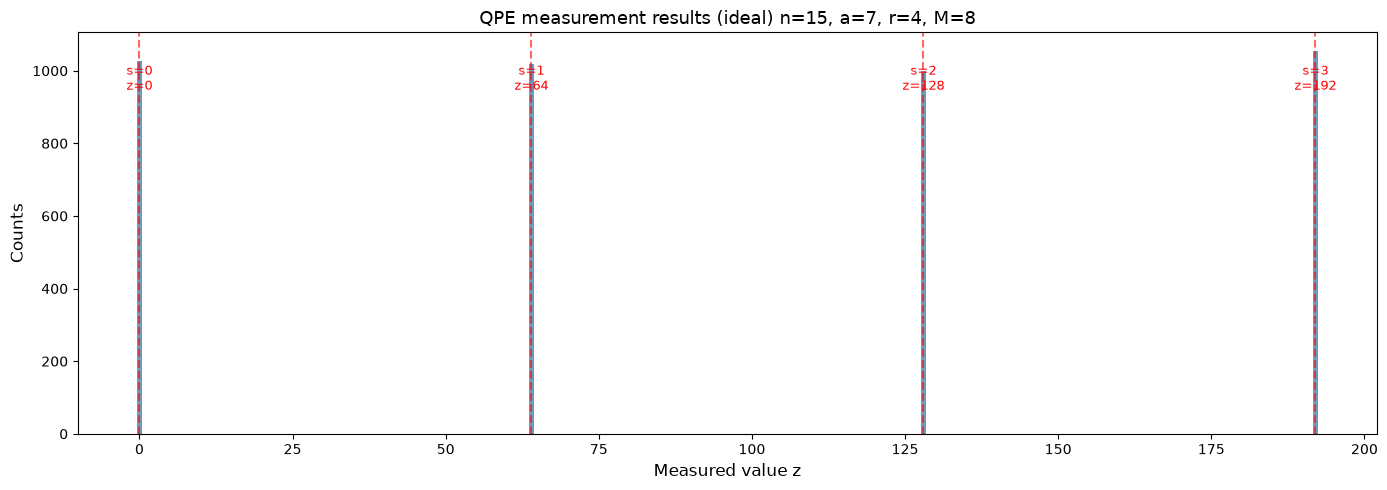

Theoretical peak positions: z = s·2^M/r = [0, 64, 128, 192]
Corresponding phases: s/r = ['0/4', '1/4', '2/4', '3/4']


In [31]:
# --- Run on the ideal simulator ---

# Prepare a noiseless simulator (SEED ensures reproducibility)
sim_ideal = AerSimulator(seed_simulator=SEED)

# Run the completed circuit qc shots times and obtain the distribution of measured values
print(f"Running the simulation ({shots} shots)...")
t_start = time.time()
qc_ideal_t = transpile(qc, sim_ideal, optimization_level=0)
result_ideal = sim_ideal.run(qc_ideal_t, shots=shots, seed_simulator=SEED).result()
counts_ideal = result_ideal.get_counts()  # dictionary of {'bitstring': count}
print(f"Simulation complete: {time.time() - t_start:.1f} s")

# --- Display the measurement results as a table ---
# Theoretical peak positions: z = s * 2^M / r (s = 0, 1, ..., r-1)
expected_peaks = {round(s * 2**M / r_true): s for s in range(r_true)}

print(f"\n=== Measurement results (top 10) ===")
print(f"{'z':>5s}  {'z/2^M':>8s}  {'counts':>6s}  {'theo. peak':>10s}")
print("-" * 40)

sorted_counts = sorted(counts_ideal.items(), key=lambda x: x[1], reverse=True)
for bitstring, count in sorted_counts[:10]:
    z = int(bitstring, 2)          # convert the bitstring to an integer
    phi = z / (2 ** M)             # the value corresponding to z/2^M = s/r
    peak_str = f"s={expected_peaks[z]}" if z in expected_peaks else ""
    print(f"{z:>5d}  {phi:>8.4f}  {count:>6d}  {peak_str:>10s}")

# --- Draw the histogram ---
# Horizontal axis: measured value z (0-255); vertical axis: counts
fig, ax = plt.subplots(figsize=(14, 5))

z_values = {}
for bitstring, count in counts_ideal.items():
    z = int(bitstring, 2)
    z_values[z] = z_values.get(z, 0) + count

zs = sorted(z_values.keys())
counts_list = [z_values[z] for z in zs]

ax.bar(zs, counts_list, color='steelblue', alpha=0.8)

# Overlay red dashed lines at the theoretical peak positions
for s in range(r_true):
    z_exp = round(s * 2**M / r_true)
    ax.axvline(x=z_exp, color='red', linestyle='--', alpha=0.6)
    ax.text(z_exp, max(counts_list) * 0.9, f's={s}\nz={z_exp}',
            ha='center', fontsize=9, color='red')

ax.set_xlabel('Measured value z', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.set_title(f'QPE measurement results (ideal) n={n_number}, a={a}, r={r_true}, M={M}', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Theoretical peak positions: z = s·2^M/r = {[round(s * 2**M / r_true) for s in range(r_true)]}")
print(f"Corresponding phases: s/r = {[f'{s}/{r_true}' for s in range(r_true)]}")

### **How to Get the Order $r$ from the Measured Value $z$**

At this point, the quantum part of Shor's algorithm is complete. For the worked example $n=15, a=7$, we built up the circuit through Steps 1–5, ran it, and confirmed that peaks appear at the four positions of the measured value $z = 0, 64, 128, 192$\
 (Note: since this is an ideal simulator, agreeing with the theory is only to be expected, but the run serves as a verification of the circuit implementation and as a baseline for the later noise experiments).

At this point, however, all we have obtained is "the integer $z$" — the prime factors $p, q$ have not been found yet. As we confirmed in Chapter 1, the order $r$ alone is enough to factor, so we need to recover $r$ from $z$ by classical computation.



Let us recall here what $z$ actually is. What we carried out in Steps 1–5 is quantum phase estimation (QPE). QPE is a mechanism that reads out the phase $\frac{s}{r}$ of the eigenvalue $e^{2\pi i s/r}$ of the modular multiplication operator $U_{a,n}$ (→ Book, "The Modular Multiplication Operator"), and the measured value $z$ is the following integer: the phase multiplied by $2^M$.

$$z = \frac{s \cdot 2^M}{r}$$

 (Note: since the control register has $M$ qubits, the phase in $0$–$1$ is mapped to an integer in $0$–$2^M-1$. → Book, "Quantum Phase Estimation") \
In other words, dividing the measured value $z$ by $2^M$ gives $\frac{s}{r}$, whose denominator is the order $r$. All that remains is to extract this denominator, and we implement that in Step 6 next.

$$z \xrightarrow{\div 2^M} \frac{s}{r} \xrightarrow{\text{extract the denominator}} r \xrightarrow{\text{method of Chapter 1}} p, q$$

### **Step 6: Recovering the Order from the Measurement via Continued Fractions, and Factoring**

(→ Book, "The Steps of Shor's Algorithm", Steps 5–6)

Now we want to extract the denominator $r$ of $\frac{z}{2^M} = \frac{s}{r}$. If $s \cdot 2^M$ is divisible by $r$, a simple reduction to lowest terms is enough; if it is not, $z$ is only an approximation of $\frac{s \cdot 2^M}{r}$, so a technique for recovering the exact denominator (the continued-fraction expansion) is needed.

**⭐ The divisible case (our $n=15$ falls into this case)**

For example, with $z=64, M=8$, simple division alone yields the order.


$$\frac{z}{2^M} = \frac{64}{256} = \frac{1}{4} \quad \Rightarrow \quad \text{denominator} = 4 = r$$


**⭐ The non-divisible case**

In general, when $2^M / r$ is not an integer, $z$ is the integer obtained by rounding $\frac{s \cdot 2^M}{r}$, so $\frac{z}{2^M}$ is only an approximation of $\frac{s}{r}$. The continued-fraction expansion is what recovers the exact denominator $r$ from this approximation.

The continued-fraction expansion is a technique that decomposes a real number into the following form by repeating the operation "take out the integer part, then take the reciprocal of the remainder."

$$\frac{z}{2^M} = a_0 + \cfrac{1}{a_1 + \cfrac{1}{a_2 + \cdots}}$$


If the number of qubits $M$ in the control register satisfies $M \geq 2\lceil \log_2 n \rceil$ for the number $n$ to be factored, it is guaranteed that $\frac{s}{r}$ (or its reduced form) appears among the convergents of the continued-fraction expansion. Here $M = 8 \geq 2\lceil \log_2 15 \rceil = 8$, so this condition is met. For details, see the Book, "The Steps of Shor's Algorithm".

**About the implementation**

In Python, `Fraction(z, 2**M).limit_denominator(n)` returns the best approximating fraction with denominator at most $n$. That denominator is the order $r$ (or a divisor of it).

Below, we implement a function that goes from the measured value $z$ through order recovery → factorization, and check it on a worked example.

> **What to do**\
● Implement the function `classify_measurement`, which recovers the order $r$ from the measured value $z$ and carries the process through to factorization. Both the divisible and non-divisible cases can be handled uniformly with `Fraction.limit_denominator`.\
● Confirm that for the example $z=64$, $r=4$ is recovered and $15 = 3 \times 5$ is obtained.

In [32]:
# --- Step 6: Measured value → order recovery → factorization ---

def classify_measurement(z: int, M_ctrl: int, a: int, n: int, max_mult: int = None) -> dict:
    """Recover the order r from the measured value z and attempt factorization (Book, "The Steps of Shor's Algorithm", Steps 5-6) """

    # Default max_mult to n (to avoid missing cases for general n)
    if max_mult is None:
        max_mult = n

    # (1) Compute z/2^M
    phi = z / (2 ** M_ctrl)

    # If z=0, the phase is 0, so the order cannot be recovered
    if z == 0:
        return {'z': z, 'phi': phi, 'r': None,
                'factors': None, 'status': 'alg_fail_2_phase0'}

    # (2) Extract the denominator via the continued-fraction expansion
    #    Fraction(z, 2**M_ctrl) builds the exact rational number z/2^M, and
    #    limit_denominator(n) returns the best approximating fraction with denominator at most n
    frac = Fraction(z, 2 ** M_ctrl).limit_denominator(n)
    r_base = frac.denominator

    # (3) r_base is not necessarily the order r itself (it may be a divisor of r)
    #    Example: s/r = 2/4 → reduced to 1/2 → r_base=2, but the true order is r=4
    #    So we try multiples of r_base and check whether each is the order: find one satisfying a^r_try ≡ 1 (mod n)
    r = None
    for mult in range(1, max_mult + 1):
        r_try = r_base * mult
        if r_try > n:
            break
        if r_try > 0 and pow(a, r_try, n) == 1:
            r = r_try
            break

    if r is None:
        return {'z': z, 'phi': phi, 'r': r_base,
                'factors': None, 'status': 'alg_fail_2_r_not_order'}

    # (4) Factor with the method from Chapter 1 (Conditions 1 and 2 → obtain the prime factors via gcd)
    result = factorize_from_order(a, n, r)
    if result['status'] == 'success':
        return {'z': z, 'phi': phi, 'r': r,
                'factors': result['factors'], 'status': 'success'}
    else:
        return {'z': z, 'phi': phi, 'r': r,
                'factors': None, 'status': f'alg_fail_1_{result["status"]}'}


# --- Worked example: check (1)-(4) above with z=64 ---
print(f"=== Worked example of the continued-fraction expansion: n={n_number}, a={a}, M={M} ===")
print()

z_example = round(1 * 2**M / r_true)  # the s=1 peak → z=64
phi_example = z_example / (2 ** M)     # (1) z/2^M
frac_example = Fraction(z_example, 2**M).limit_denominator(n_number)  # (2) continued-fraction expansion

print(f"(1) z/2^M = {z_example}/{2**M} = {phi_example}")
print(f"(2) Continued-fraction expansion → {frac_example} (denominator = {frac_example.denominator}) ")
print(f"   Check: {a}^{frac_example.denominator} mod {n_number} = {pow(a, frac_example.denominator, n_number)}")
print(f"(3) Order r = {frac_example.denominator}")
print(f"(4) Factoring with the method from Chapter 1:")

result_example = classify_measurement(z_example, M, a, n_number)
if result_example['factors']:
    p, q = result_example['factors']
    print(f"   {n_number} = {p} × {q}")

=== Worked example of the continued-fraction expansion: n=15, a=7, M=8 ===

(1) z/2^M = 64/256 = 0.25
(2) Continued-fraction expansion → 1/4 (denominator = 4) 
   Check: 7^4 mod 15 = 1
(3) Order r = 4
(4) Factoring with the method from Chapter 1:
   15 = 5 × 3


### **Supplement: The Algorithm's Success Probability (→ Book, "Success Probability and Overall Complexity")**


Whenever such a failure occurs, it suffices to pick a different $a$ or simply rerun the algorithm. The classical success probability associated with the choice of $a$ is $\geq 1/2$ (→ Book, "Success Probability and Overall Complexity"). The overall success probability of a single trial—including the finite precision of QPE and the requirement $\gcd(s,r)=1$—is $\Omega(1/\log \log n)$ in the worst case, but in practice roughly $O(1)$ retries are usually enough.

Even if a run fails, the probability of succeeding within $k$ reruns approaches $1$ rapidly.

In other words, since failures are fixed by a small number of retries, the cost of retrying does not affect the order of the overall complexity. The analysis that follows focuses on computational cost, and in that discussion we can ignore retries and concentrate solely on the cost of a single circuit execution.

### **Factorization Completed with Shor's Algorithm**

This completes all the steps of Shor's algorithm: we have successfully factored $n = 15$ into $3 \times 5$.\
 (※ This hands-on used $n=15, a=7$ as the worked example, but the same circuit works for other values if you change $n$ and $a$ in the parameter cell at the beginning.)

Looking back, the only part the quantum computer handled was **order finding** in Steps 1–5. In Chapter 1 we confirmed that "once you know the order, you can factor," and saw firsthand that naive classical computation takes exponential time to find that order (even the best known classical method takes subexponential time). The quantum circuit carried out this order finding, and in Step 6 we returned to classical computation to complete the factorization.

| Step | What happens | Type of computation |
|---------|------|----------|
| Chapter 1 | Confirm that once the order $r$ is known, we can factor using $\gcd$ | Classical |
| Steps 1–2 | Initialize the registers and create a superposition with Hadamard gates | Quantum |
| Step 3 | Embed the period-$r$ structure into the quantum state via controlled modular exponentiation | Quantum |
| Steps 4–5 | Convert the period into peaks with the inverse QFT, and obtain $z$ by measurement | Quantum |
| Step 6 | Recover $r=4$ from $z$ via the continued-fraction expansion, then $15 = 3 \times 5$ by $\gcd$ | Classical |

As for the success probability, as we confirmed in the previous cell, the cost of retries does not affect the order of the complexity.

The complexity (gate count) of Shor's algorithm is $O(L^3)$ ($L = \log_2 n$), an overwhelming advantage over the subexponential time of classical methods (→ Book, "Comparison with Classical Algorithms"). **Because it runs in polynomial time even as $n$ grows, it can in principle break any RSA key, including RSA-2048.**

## 3. **Analysis**

### 3.1 Today's Quantum Computers (NISQ) Cannot Break RSA

We have confirmed that Shor's algorithm can, in principle, break RSA. However, everything so far was run on an ideal simulator—which amounts to assuming a world in which FTQC (an error-corrected quantum computer) has been realized.

Real qubits suffer noise (errors) from gate operations and interactions with the environment. To suppress this noise, we need to bundle multiple physical qubits together and perform error correction, building "**logical qubits**" that behave like single error-free qubits—that is, we need to realize FTQC (→ Book, "Challenges with Current Technology"). At present, however, we are far from realizing an FTQC large enough to break RSA.

**Logical qubit counts today**\
As of November 2025, the largest demonstrated number of logical qubits is 96 (distance $d=4$) [10b].

**Estimated quantum resources needed for RSA-2048**\
Estimates of the quantum resources needed to break RSA-2048 with Shor's algorithm vary depending on the implementation approach and assumptions. Representative estimates are shown below.

| Estimate | Quantum resources | Notes |
|---------|---------|------|
| Gidney & Ekerå (2021) [1] | About 20 million physical qubits (about 6,189 logical qubits) | Surface code + magic state distillation. The widely cited baseline |
| Ragavan & Vaikuntanathan (2024) [11] | $O(n \log n)$ qubits + $O(\sqrt{n})$ sequential runs | An improvement of Regev's algorithm; a line of research aimed at drastically reducing the qubit count |
| Gidney (2025) [12] | Fewer than 1 million physical (noisy) qubits | A large reduction from the 20 million of [1], thanks to more efficient distillation |

As these show, the estimates improve year by year, but in every case there remains a large gap between these requirements and the tens to about a hundred logical qubits demonstrated today. Moreover, it is one thing to have "created" logical qubits; running large-scale quantum operations on them stably is harder still.

Today's mainstream devices are **NISQ** (noisy intermediate-scale quantum) devices, which lack error correction. On NISQ hardware, noise accumulates with every gate operation—and given that even the $n=15$ circuit requires thousands of gates, the impact is severe.

So how badly would the results degrade if we ran Shor's algorithm on a current NISQ device? Below—purely in simulation—we add noise and observe what changes.


※ NISQ devices are not designed to run deep circuits like Shor's algorithm, so failure is expected. What follows is offered as a reference: a look at just how badly things go in a noisy environment.

### **3.2 Noise Model and Experimental Conditions**

On current NISQ devices, even the $n=15$ Shor circuit (18 qubits) is difficult to run on real hardware. So here we **deliberately inject noise** in the simulator and observe how the results change.

There are several kinds of noise models for quantum computers (amplitude damping, phase damping, the depolarizing channel, and so on; → discussed in detail in Book, "Challenges with Current Technology"). Here we use the **depolarizing channel**: a model in which, after each gate operation, a random Pauli error occurs with a fixed probability $p_{cx}$. It is widely used for rough estimates of the impact of noise. The Book's "Challenges with Current Technology" section carries out a theoretical analysis using the same model; here we confirm it in an actual simulation.

We also apply noise to **CX gates (two-qubit gates) only**. This is because CX gates have error rates more than 10 times higher than those of one-qubit gates and account for most of the error in the whole circuit (→ Book, "Challenges with Current Technology").

The experimental conditions are summarized below.

| Item | Setting |
|------|------|
| **Noise model** | Depolarizing channel (applied to CX gates only; → Book, "Challenges with Current Technology")  |
| **Error rate** | $p_{cx} = 0, 0.001, 0.01$ (CX error rates for superconducting devices are $\sim 0.5\text{--}1\%$ [6]; → Book, "Challenges with Current Technology", table)  |
| **Circuit** | The $n=15$ Shor circuit built so far, used unchanged |

If a CX gate with error rate $p_{cx}$ is applied $N_{cx}$ times, the probability that every gate works correctly is $(1-p_{cx})^{N_{cx}}$, which decays rapidly (→ Book, "Challenges with Current Technology"). We will count the CX gates in the circuit in the next code cell; even if $p_{cx}$ is small, a large $N_{cx}$ means the correct result is almost never obtained. **No number of additional shots can compensate for this.**

### **3.3 Adding the Noise Model in Qiskit**

Qiskit Aer has built-in support for noisy simulation. Concretely, there are two steps:

1. **Build the noise model**\
Create a noise-model object with `NoiseModel()`, then use `depolarizing_error(p_cx, 2)` to generate and register "a depolarizing error with error rate $p_{cx}$ on two-qubit gates." As a result, at run time a random error is inserted with probability $p_{cx}$ for every CX gate in the circuit
2. **Pass it to the simulator**\
Create a simulator with the noise model set via `AerSimulator(noise_model=...)`, and run the same circuit `qc` as before, unchanged

The circuit itself is therefore never modified. In "Running Shor's Algorithm" we ran on the ideal simulator with `sim_ideal = AerSimulator()`; all we do now is swap in a simulator with the noise model set (`AerSimulator(noise_model=...)`) and run the same circuit `qc`.

Below we run under three conditions—$p_{cx} = 0$ (ideal, for comparison), $0.001$, and $0.01$—and compare the histograms of the measurement results (horizontal axis: measured value $z$; vertical axis: counts). We observe how the four peaks that stood at $z = 0, 64, 128, 192$ in the ideal case collapse as the noise increases.

### **3.4 Running with the Noise Model**

> **What to do**\
● Run the circuit `qc` for $n=15, a=7$, already built in Steps 1–5, with no noise ($p_{cx}=0$, for comparison) and at two noise levels ($p_{cx}=0.001, 0.01$). Do not modify the circuit; just set a `noise_model` on the simulator.\
 (※ You can also run with other $n, a$ by changing the parameters at the beginning)   \
● Compare the success rate at each noise level and the histograms of the measured value $z$, and watch how the four peaks that stood at $z=0, 64, 128, 192$ in the ideal case collapse as the noise increases.

> ※ This cell may take several minutes to run.

=== Noise experiment ===
Circuit in use: n=15, a=7, M=8
Number of qubits: 18, number of CX gates: 128

Simulating with p_cx = 0.0000... 

Success rate = 0.7500 [5.6 s]
Simulating with p_cx = 0.0010... 

Success rate = 0.3125 [21.2 s]
Simulating with p_cx = 0.0100... 

Success rate = 0.1250 [20.3 s]

All noise levels completed


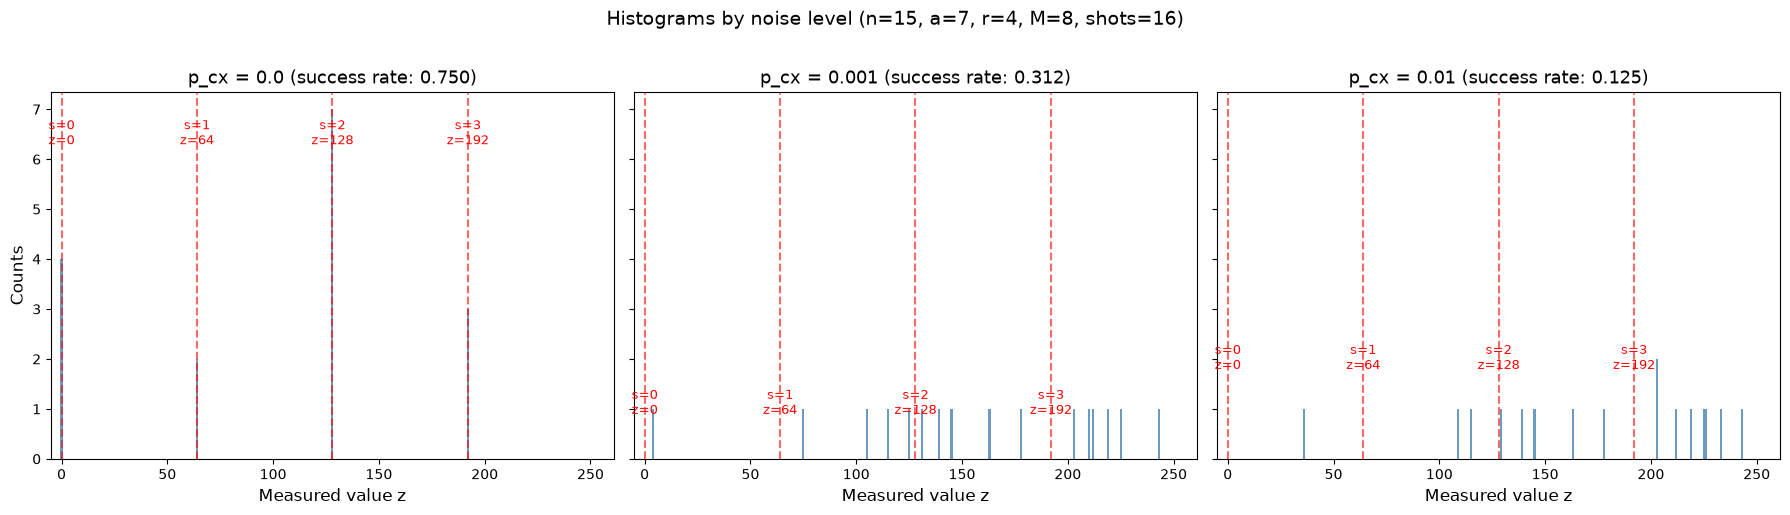

Theoretical peak positions: z = s·2^M/r = [0, 64, 128, 192]
The red dashed lines mark the theoretical peaks. As the noise increases, the peak structure washes out and the distribution approaches uniform.


In [33]:
# --- Noise experiment ---
# Use the circuit qc built so far, unchanged
# The only difference from the "Running Shor's Algorithm" cell is passing noise_model to AerSimulator

noise_shots = 16  # Lightweight setting for a rough look at the shape. Not enough for precise success-rate comparisons; raise to 256-1024 if needed (it takes a while, though...)

# Check the number of CX gates (this is where the noise enters)
qc_transpiled = transpile(qc, AerSimulator())
n_cx = qc_transpiled.count_ops().get('cx', 0)
print(f"=== Noise experiment ===")
print(f"Circuit in use: n={n_number}, a={a}, M={M}")
print(f"Number of qubits: {qc.num_qubits}, number of CX gates: {n_cx}")
print()

# --- Run at three noise levels ---
p_cx_values = [0.0, 0.001, 0.01]  # List of error rates to compare
noise_results = {}                         # Dictionary storing the measurement results for each error rate

for p in p_cx_values:
    print(f"Simulating with p_cx = {p:.4f}...", end=" ")
    t_start = time.time()

    if p == 0:
        # p_cx = 0: no noise (same as the ideal simulator, for comparison)
        sim = AerSimulator(method='statevector', seed_simulator=SEED)
    else:
        # p_cx > 0: create a noise model and set it on the simulator
        noise_model = NoiseModel()                          # Create an empty noise model
        error_cx = depolarizing_error(p, 2)                 # Generate a two-qubit depolarizing error
        noise_model.add_all_qubit_quantum_error(error_cx, ['cx'])  # Apply to all CX gates
        sim = AerSimulator(method='statevector', noise_model=noise_model, seed_simulator=SEED)

    # The rest is the same flow as with the ideal simulator
    qc_t = transpile(qc, sim, optimization_level=0)         # Use the circuit as is (avoid numerical error from optimization)
    result = sim.run(qc_t, shots=noise_shots, seed_simulator=SEED).result()  # Run
    counts = result.get_counts()                             # Dictionary of {'bitstring': count}
    noise_results[p] = counts                                # Save the results

    # Compute the success rate (classify_measurement was defined in Step 6)
    success_count = sum(
        cnt for bs, cnt in counts.items()
        if classify_measurement(int(bs, 2), M, a, n_number)['status'] == 'success'
    )
    total = sum(counts.values())
    t_elapsed = time.time() - t_start
    print(f"Success rate = {success_count/total:.4f} [{t_elapsed:.1f} s]")

print("\nAll noise levels completed")





# --- Compare histograms across noise levels ---
# Horizontal axis: measured value z (0 to 2^M-1); vertical axis: counts
# sharey + a common xlim make the three plots directly comparable
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Prepare counts for all z values (0 to 2^M-1) in a uniform format
all_zs = list(range(2**M))

for idx, (p_val, ax) in enumerate(zip(p_cx_values, axes.flat)):
    counts = noise_results[p_val]

    # Convert bitstrings to integers and tally (zero-filled over all z)
    z_counts = [0] * (2**M)
    for bitstring, count in counts.items():
        z = int(bitstring, 2)
        z_counts[z] += count

    ax.bar(all_zs, z_counts, width=1.0, color='steelblue', alpha=0.8)

    # Overlay red dashed lines at the theoretical peak positions
    max_count = max(z_counts) if max(z_counts) > 0 else 1
    for s in range(r_true):
        z_exp = round(s * 2**M / r_true)
        ax.axvline(x=z_exp, color='red', linestyle='--', alpha=0.6)
        ax.text(z_exp, max_count * 0.9, f's={s}\nz={z_exp}',
                ha='center', fontsize=9, color='red')

    # Compute the success rate and show it in the title
    success_count = sum(
        cnt for bs, cnt in counts.items()
        if classify_measurement(int(bs, 2), M, a, n_number)['status'] == 'success'
    )
    total = sum(counts.values())

    ax.set_title(f'p_cx = {p_val} (success rate: {success_count/total:.3f})', fontsize=13)
    ax.set_xlabel('Measured value z', fontsize=12)
    ax.set_xlim(-5, 2**M + 5)
    if idx == 0:
        ax.set_ylabel('Counts', fontsize=12)

plt.suptitle(f'Histograms by noise level (n={n_number}, a={a}, r={r_true}, M={M}, shots={noise_shots})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Theoretical peak positions: z = s·2^M/r = {[round(s * 2**M / r_true) for s in range(r_true)]}")
print(f"The red dashed lines mark the theoretical peaks. As the noise increases, the peak structure washes out and the distribution approaches uniform.")

The histograms show that as the noise increases, the peak structure at $z = 0, 64, 128, 192$ collapses and the measured values spread out toward a uniform distribution.

In the ideal case, one of $z = 0, 64, 128, 192$ appears with equal probability, and for any outcome other than $z=0$ the continued-fraction expansion recovers the order $r=4$, so the factorization succeeds. Even with noise, if a $z$ at a correct peak position happens to come out, the factorization still succeeds. The problem is that noise drastically reduces the very probability of obtaining a $z$ at a peak position. Once the peaks collapse, unrelated values (for example, $z=37$) become more likely to appear in place of the correct $z$, and the continued-fraction expansion no longer yields the correct order.

Could we then detect the peaks statistically by increasing the number of shots? If the probability at the peak positions were even slightly higher than elsewhere, then in principle, yes. However, as an approximation building on the discussion in the Book, "Challenges with Current Technology": after passing through $N_{cx}$ CX gates, the measurement probability distribution approaches a mixture of the ideal peak distribution and the uniform distribution (the typical behavior of depolarizing noise).

$$P(z) = (1-p_{cx})^{N_{cx}} \cdot P^{(\text{ideal})}(z) + \left(1 - (1-p_{cx})^{N_{cx}}\right) \cdot \frac{1}{2^M}$$

The factor $(1-p_{cx})^{N_{cx}}$ corresponds to the strength of the peak signal. In this hands-on's $n=15$ circuit, $N_{cx}=128$, so even at $p_{cx}=0.005$ we have $(1-0.005)^{128} \approx 0.53$—about half the signal still remains. On the other hand, with $N_{cx}$ around 5000, $p_{cx}=0.005$ gives $(1-0.005)^{5000} \approx 10^{-11}$, and the probability of obtaining the correct result becomes effectively zero. For a circuit at the scale of RSA-2048, $N_{cx}$ is on the order of $10^9$, putting execution even further out of reach. Detecting such a minuscule probability difference statistically would require $\sim 10^{22}$ shots, which cannot be achieved in any realistic amount of time.

Moreover, this simulation models only the depolarizing error on CX gates; on real devices, multiple additional noise sources pile on top of it—one-qubit gate errors, decoherence (T1/T2 relaxation), measurement errors, crosstalk, and more (→ Book, "Challenges with Current Technology"). In other words, our results are an optimistic estimate, and real devices are harsher still.


In short, on NISQ devices without error correction, even proceeding to Step 6—recovering the order from the measurement results of Shor's algorithm—is not realistically possible. Without the error correction provided by FTQC, Shor's algorithm does not work in practice.

### **Box: Technical Challenges on the Road to FTQC**

As the noise experiment above confirmed, Shor's algorithm does not work in practice on NISQ devices without error correction. Running Shor's algorithm requires FTQC with error correction—but realizing it is not easy.

The field is currently at the stage of increasing the number of logical qubits, but running large-scale circuits stably on top of them is harder still. Beyond the gap in logical qubit counts and the scaling-up of physical qubits, realizing FTQC also poses technical challenges in actually executing circuits.

For example, among the phase-rotation gates `PhaseGate(θ)` used to build the Draper adder in this hands-on, those whose $\theta$ is not a multiple of $\pi/2$ (for example $\pi/4$ or $\pi/8$) are classified as non-Clifford gates; the representative example is the T gate ($\theta = \pi/4$). Because the Draper adder is invoked hierarchically—Level 1 (modular addition) → Level 2 (modular multiplication) → controlled modular exponentiation—the full circuit requires a huge number of non-Clifford gates. Under an error-correcting code (such as the surface code), however, these gates cannot be implemented directly. Instead, a procedure called "magic state distillation" repeatedly purifies noisy quantum states to produce high-purity auxiliary states, which are then consumed to realize T gates. This distillation demands large numbers of physical qubits and much time, and is estimated to account for the majority of FTQC's resources (Bravyi & Kitaev (2005) [7], Gidney & Fowler (2019) [8]).

In addition, error correction repeatedly performs syndrome measurements (operations that use ancilla qubits to check whether errors have occurred), and the results must be processed and fed back in real time before the next gate operation (real-time decoding). The measurement–classical-computation–feedback cycle must fit within the time scale of a gate operation, placing extremely high demands on the control systems (Google Quantum AI (2025) [9]).


Against this backdrop, standardization of post-quantum cryptography (PQC)—cryptography resistant to quantum computers—is also under way: NIST finalized ML-KEM, ML-DSA, and SLH-DSA in August 2024. The threat of "harvest now, decrypt later" (recording encrypted communications today to decrypt them with a future FTQC) is also being discussed (→ Book, "Challenges with Current Technology").

---

## **Summary**



One of the main reasons quantum computers attract so much public attention is the possibility that Shor's algorithm could break RSA encryption. RSA underpins the foundations of today's Internet security, and the impact of its security collapsing would be immeasurable.



In this hands-on, we implemented and ran Shor's algorithm itself from scratch on the worked example $n=15, a=7$, experiencing the entire process of factoring with a quantum computer. We hope you now understand how a quantum computer breaks RSA encryption—and why it does not yet work on today's devices.


| Chapter / Step | What we confirmed |
|-------------|------------|
| **Chapter 1 (classical)** | Once the order $r$ is known, factoring takes nothing more than $\gcd$. But naive classical computation takes exponential time to find the order (even the best known classical method takes subexponential time), which is practically impossible at the scale of RSA-2048 |
| **Steps 1–5 (quantum)** | Built the QPE circuit based on Beauregard's Fourier-space arithmetic and ran it on the ideal simulator; confirmed that peaks appear at the four measured values $z = 0, 64, 128, 192$ |
| **Step 6 (classical)** | Recovered the order $r=4$ from $z$ via the continued-fraction expansion and successfully factored $15 = 3 \times 5$ |
| **Success probability** | The classical success probability associated with the choice of $a$ is $\geq 1/2$. The overall per-trial success probability, including the finite precision of QPE and other factors, is $\Omega(1/\log \log n)$ in the worst case, but in practice $O(1)$ retries suffice |
| **Complexity** | Shor's algorithm runs in $O(L^3)$, an overwhelming advantage over classical subexponential time. In principle it can break any RSA key, including RSA-2048 (→ Book, "Comparison with Classical Algorithms")  |
| **Circuit scale** | Estimates of the physical qubits needed for RSA-2048 are improving—from about 20 million in Gidney & Ekerå (2021) [1] to fewer than 1 million in Gidney (2025) [12]—but a large gap still remains from what has been demonstrated so far (96 logical qubits [10b], as of November 2025) (→ Book, "Challenges with Current Technology") |
| **Noise experiment** | Even a small amount of noise collapses the peak structure and drastically reduces the probability of obtaining a correct $z$. Increasing the shots does not recover the signal. And this is an optimistic estimate—real devices are harsher still |



Quantum computing is a topic that is sometimes wildly overhyped, described as if it were magic. What can it do today, and what can it not do yet? Rather than being swept along by sensational headlines, we want to keep learning so that we can verify and judge these claims with our own hands.

In addition to this hands-on, there is also a theoretical companion document; interested readers are encouraged to consult it.

---

## **References**

> **Note**: The reference numbers in this hands-on are independent of the numbering scheme in the Book (the PDF); numbers are assigned in order of appearance within each medium. The same paper may therefore carry a different number here than in the Book, so when tracing a citation, please look it up by author name and title.


| # | Reference |
|---|------|
| [1] | Gidney, C. & Ekerå, M. (2021). How to factor 2048 bit RSA integers in 8 hours using 20 million noisy qubits. *Quantum*, 5, 433. [arXiv:1905.09749](https://arxiv.org/abs/1905.09749) |
| [2] | Shor, P. W. (1997). Polynomial-Time Algorithms for Prime Factorization and Discrete Logarithms on a Quantum Computer. *SIAM J. Comput.*, 26(5), 1484–1509. [arXiv:quant-ph/9508027](https://arxiv.org/abs/quant-ph/9508027) |
| [3] | Beauregard, S. (2003). Circuit for Shor's algorithm using 2n+3 qubits. *Quantum Information & Computation*, 3(2), 175–185. [arXiv:quant-ph/0205095](https://arxiv.org/abs/quant-ph/0205095) |
| [4] | Draper, T. G. (2000). Addition on a Quantum Computer. [arXiv:quant-ph/0008033](https://arxiv.org/abs/quant-ph/0008033) |
| [5] | Nielsen, M. A. & Chuang, I. L. (2010). *Quantum Computation and Quantum Information*. 10th Anniversary Edition. Cambridge University Press. |
| [6] | Kjaergaard, M. et al. (2020). Superconducting Qubits: Current State of Play. *Annual Review of Condensed Matter Physics*, 11, 369–395. |
| [7] | Bravyi, S. & Kitaev, A. (2005). Universal quantum computation with ideal Clifford gates and noisy ancillas. *Phys. Rev. A*, 71, 022316. [arXiv:quant-ph/0403025](https://arxiv.org/abs/quant-ph/0403025) |
| [8] | Gidney, C. & Fowler, A. G. (2019). Efficient magic state factories with a catalyzed $|CCZ\rangle$ to $2|T\rangle$ transformation. *Quantum*, 3, 135. [arXiv:1812.01238](https://arxiv.org/abs/1812.01238) |
| [9] | Google Quantum AI (2025). Quantum error correction below the surface code threshold. *Nature*, 638, 920–926 (online 2024-12-09). |
| [10] | Bluvstein, D. et al. (2024). Logical quantum processor based on reconfigurable atom arrays. *Nature*, 626, 58–65. |
| [10b] | Bluvstein, D. et al. (2026). A fault-tolerant neutral-atom architecture for universal quantum computation. *Nature*, 649, 39–46 (published online 2025-11-10). [doi:10.1038/s41586-025-09848-5](https://doi.org/10.1038/s41586-025-09848-5) (Demonstration of up to 96 logical qubits at distance $d=4$; a follow-up to [10].) |
| [11] | Ragavan, S. & Vaikuntanathan, V. (2024). Space-Efficient and Noise-Robust Quantum Factoring. *CRYPTO 2024*. [arXiv:2310.00899](https://arxiv.org/abs/2310.00899) |
| [12] | Gidney, C. (2025). How to factor 2048 bit RSA integers with less than a million noisy qubits. [arXiv:2505.15917](https://arxiv.org/abs/2505.15917) |

**Note**: Quantum computing hardware performance and resource estimates are being updated rapidly. The figures in this hands-on reflect the state at the time of writing; for the latest status, see the individual references and announcements from the relevant organizations.